# VIX – Volatilitätsbasierte Frühindikatoren für ein Ampelsystem

### Eine explorative Datenanalyse des „Angstbarometers“ (CBOE VIX)

Diese Analyse untersucht neun Hypothesen zur Aussagekraft des VIX (CBOE
Volatility Index) und verwandter Kennzahlen als Bausteine für ein
indikatorbasiertes **Ampelsystem** (Grün = ruhiges Fahrwasser, Gelb =
angespannt, Rot = Ausnahmezustand), das den aktuellen Marktzustand für
eine automatisierte Morgenroutine im Börsenhandel einordnet. Ziel ist die
Identifikation robuster, statistisch nachvollziehbarer Signale sowie die
datenbasierte Herleitung sinnvoller Ampel-Schwellenwerte.

Jede Hypothese wird in einheitlichen Schritten behandelt: Vorstellung und
Motivation, statistische bzw. grafische Auswertung, Interpretation der
Ergebnisse in allgemeinverständlicher Sprache sowie eine Einschätzung der
praktischen Relevanz für das Ampelsystem.

**Aufbau:**

1. Datenbezug und Aufbereitung
2. Datenqualität und Aufbereitung
3. Methodik und Hypothesenübersicht
4. Hypothesenanalyse
5. Vertiefte Einzelbetrachtung
6. Fazit und Handlungsempfehlungen


## 1. Datenbezug und Aufbereitung

Grundlage der Analyse sind historische Tageskursdaten des VIX sowie des
S&P 500 als Vergleichsindex. Dieser Abschnitt beschreibt die verwendeten
Software-Werkzeuge und den Datenbezug.


### 1.1 Verwendete Bibliotheken und Konfiguration

- **pandas** – Datenstrukturen und -verarbeitung (tabellarische Zeitreihen).
- **numpy** – numerische Berechnungen.
- **matplotlib** / **seaborn** – grafische Auswertung.

Zentral definiert werden zudem der Datenpfad sowie die einheitlichen
Ampelfarben (Grün/Gelb/Rot) für sämtliche Diagramme des Notebooks.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR = "../data"

# Ampel-Farben fuer konsistente Plots
COLOR_GREEN = "#2ca02c"
COLOR_YELLOW = "#f2c811"
COLOR_RED = "#d62728"

### 1.2 Datenbezug

Die Rohdaten wurden zuvor per `src/fetch_data.py` über die Programmier-
schnittstelle von Yahoo Finance bezogen (Ticker `^VIX` und `^GSPC`, tägliche
OHLC-Daten ab dem 01.01.2007) und liegen als CSV im Ordner `data/`. Der
Zeitraum ab 2007 schließt die globale Finanzkrise 2008 als Stresstest mit ein.


In [2]:
vix = pd.read_csv(f"{DATA_DIR}/vix_raw.csv", index_col="Date", parse_dates=True)
sp500 = pd.read_csv(f"{DATA_DIR}/sp500_raw.csv", index_col="Date", parse_dates=True)

print("VIX:", vix.shape, vix.index.min().date(), "-", vix.index.max().date())
print("S&P 500:", sp500.shape, sp500.index.min().date(), "-", sp500.index.max().date())

vix.head()

VIX: (4929, 6) 2007-01-03 - 2026-08-05
S&P 500: (4927, 6) 2007-01-03 - 2026-08-04


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2007-01-03,12.04,12.04,12.75,11.53,12.16,0
2007-01-04,11.51,11.51,12.42,11.28,12.40,0
2007-01-05,12.14,12.14,12.25,11.68,11.84,0
2007-01-08,12.00,12.00,12.83,11.78,12.48,0
2007-01-09,11.91,11.91,12.47,11.69,11.86,0


## 2. Datenqualität und Aufbereitung

Vor der eigentlichen Analyse werden die Rohdaten systematisch auf typische
Qualitätsprobleme geprüft und anschließend zu einem gemeinsamen Analyse-
Datensatz zusammengeführt.


### 2.1 Datenqualitätsprüfung

Geprüft werden fehlende Werte, doppelte Datumseinträge sowie abweichende
Handelstage zwischen den beiden Zeitreihen (z. B. durch unterschiedliche
Feiertagskalender bei Yahoo Finance).


In [3]:
print("Fehlende Werte VIX:\
", vix.isna().sum())
print("\
Fehlende Werte S&P 500:\
", sp500.isna().sum())
print("\
Duplizierte Indexwerte VIX:", vix.index.duplicated().sum())
print("Duplizierte Indexwerte S&P 500:", sp500.index.duplicated().sum())

only_in_vix = vix.index.difference(sp500.index)
only_in_sp500 = sp500.index.difference(vix.index)
print(f"\
Handelstage nur im VIX: {len(only_in_vix)}")
print(f"Handelstage nur im S&P 500: {len(only_in_sp500)}")

Fehlende Werte VIX: Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Fehlende Werte S&P 500: Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Duplizierte Indexwerte VIX: 0
Duplizierte Indexwerte S&P 500: 0
Handelstage nur im VIX: 2
Handelstage nur im S&P 500: 0


### 2.2 Kombinierter Analyse-Datensatz und Zielgrößen

Beide Zeitreihen werden über die gemeinsamen Handelstage verknüpft (inner
join). Zusätzlich werden die tägliche S&P-500-Rendite (`sp500_return`, in %)
sowie die tägliche VIX-Veränderung (`vix_change`, in Punkten) als abgeleitete
Größen berechnet.


In [4]:
df = pd.DataFrame({
    "vix_close": vix["Close"],
    "sp500_close": sp500["Close"],
}).dropna()

df["sp500_return"] = df["sp500_close"].pct_change() * 100  # in %
df["vix_change"] = df["vix_close"].diff()

print(f"Gemeinsame Handelstage: {len(df)}")
df.describe()

Gemeinsame Handelstage: 4927


,vix_close,sp500_close,sp500_return,vix_change
count,4927.000000,4927.000000,4926.000000,4926.000000
mean,19.788230,2804.092701,0.042198,0.000905
std,8.700132,1669.949594,1.241855,1.986202
min,9.140000,676.530029,-11.984055,-18.710003
25%,14.090000,1418.445007,-0.413199,-0.770000
50%,17.500000,2173.600098,0.072402,-0.110000
75%,22.695001,3958.670044,0.596015,0.600000
max,82.690002,7736.520020,11.580037,24.860001


## 3. Methodik und Hypothesenübersicht


### 3.1 Ampel-Logik und statistische Referenzgrößen

Als gemeinsame Referenzgröße für die vertiefenden Hypothesen dient der
VIX-Schwellenwert **30** – die gängige Marktfaustregel für den
„Ausnahmezustand“ (Rot). Abschnitt 4.8 prüft explizit, ob sich dieser Wert
anhand der Daten bestätigen lässt.

Zur Bewertung eines Signals wird durchgängig die **Trefferquote** verwendet:
der Anteil der Signaltage, an denen der VIX innerhalb der nächsten `horizon`
Handelstage mindestens einmal über die Schwelle steigt. Sie wird stets mit
der **Baseline** (unbedingte Wahrscheinlichkeit über alle Handelstage)
verglichen, um den Mehrwert des Signals einzuordnen.

**Einschränkung:** Handelstage sind zeitlich nicht unabhängig voneinander
(hohe Autokorrelation, siehe Abschnitt 4.3). Zusammenhängende Signalphasen
bestehen häufig aus mehreren benachbarten Tagen; die berichteten Trefferquoten
sind daher als Anhaltspunkt und nicht als exakte Wahrscheinlichkeitsaussage
zu interpretieren.


In [5]:
# Gemeinsame Konfiguration fuer die folgenden Abschnitte
VIX_THRESHOLD_ROT = 30  # Faustregel-Schwelle "Ausnahmezustand", wird in Abschnitt 11 validiert


def forward_hit_rate(signal_mask, horizon, threshold=VIX_THRESHOLD_ROT):
    """Anteil der Tage mit signal_mask == True, an denen der VIX-Schlusskurs
    innerhalb der naechsten `horizon` Handelstage mindestens einmal ueber
    `threshold` steigt. Tage ohne vollstaendiges Folgefenster (zu nah am
    Datenende) werden ausgeschlossen."""
    vix_values = df["vix_close"].values
    mask_values = signal_mask.values if hasattr(signal_mask, "values") else signal_mask
    idx = np.where(mask_values)[0]
    hits, valid = 0, 0
    for i in idx:
        window = vix_values[i + 1 : i + 1 + horizon]
        if len(window) == 0:
            continue  # kein vollstaendiges Folgefenster mehr vorhanden
        valid += 1
        if window.max() > threshold:
            hits += 1
    return hits / valid if valid else np.nan


ALL_DAYS = pd.Series(True, index=df.index)

### 3.2 Untersuchte Hypothesen

| # | Hypothese | Kriterium |
|---|---|---|
| H1 | Ruhiges Fahrwasser vs. Stressphasen | Bewegt sich der VIX im ruhigen Band oder in einer Stressphase? |
| H2 | VIX vs. S&P-500-Renditen | Wie hängt die VIX-Bewegung mit der Tagesrendite des Index zusammen? |
| H3 | Volatility Clustering | Treten hohe/niedrige VIX-Werte in Clustern auf (Autokorrelation)? |
| H4 | Verteilung & Schwellenwerte | Welche Ampel-Schwellen legt die historische Verteilung nahe? |
| H5 | Dauer der Ampelphasen | Wie lange dauern zusammenhängende Grün-/Gelb-/Rot-Phasen? |
| H6 | Neues 3-Monats-Hoch | Kündigt ein neues 3-Monats-Hoch eine nachfolgende Rot-Phase an? |
| H7 | 3-Punkte-Umkehr | Signalisiert eine ausgeprägte Intraday-Umkehr eine Beruhigung? |
| H8 | VIX-Schwellenwerte | Ab welchem Niveau heben sich reale Stressphasen ab? |
| H9 | Divergenz zum Index | Kündigt untypischer Gleichlauf von VIX und Index Turbulenzen an? |

H1–H5 bilden die Basis-Exploration des VIX, H6–H9 vertiefen einzelne, für
die Ampel-Logik besonders relevante Muster. Für jede Hypothese werden das
Ergebnis interpretiert und die Praxisrelevanz für das Ampelsystem eingeordnet.


## 4. Hypothesenanalyse

Die Abschnitte 4.1–4.5 prüfen die grundlegenden Eigenschaften des VIX,
die Abschnitte 4.6–4.9 vertiefen spezifische Signalmuster. Jeder Abschnitt
enthält Code, eine Visualisierung sowie eine Ergebnis- und Praxiseinordnung.


### 4.1 H1 – Ruhiges Fahrwasser vs. Stressphasen

**Hypothese:** Der VIX bewegt sich meist in einem ruhigen Band und zeigt nur
in Stressphasen (Finanzkrise 2008, Corona-Crash 2020, Inflations-Baisse 2022)
deutliche Ausschläge nach oben. Zur visuellen Einordnung wird der
VIX-Verlauf mit farblich hinterlegten Krisenphasen und den Faustregel-Schwellen
20 und 30 dargestellt.


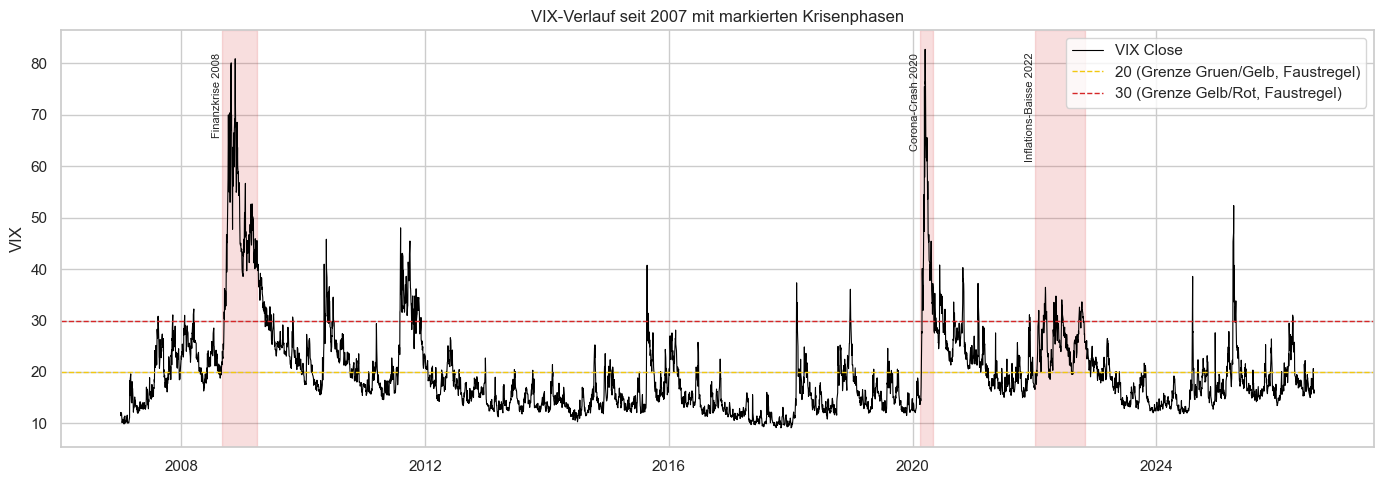

In [6]:
crisis_periods = {
    "Finanzkrise 2008": ("2008-09-01", "2009-03-31"),
    "Corona-Crash 2020": ("2020-02-15", "2020-04-30"),
    "Inflations-Baisse 2022": ("2022-01-01", "2022-10-31"),
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["vix_close"], color="black", linewidth=0.8, label="VIX Close")

for label, (start, end) in crisis_periods.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=COLOR_RED, alpha=0.15)
    ax.text(pd.Timestamp(start), ax.get_ylim()[1] * 0.95, label, fontsize=8, rotation=90,
            va="top", ha="right")

ax.axhline(20, color=COLOR_YELLOW, linestyle="--", linewidth=1, label="20 (Grenze Gruen/Gelb, Faustregel)")
ax.axhline(30, color=COLOR_RED, linestyle="--", linewidth=1, label="30 (Grenze Gelb/Rot, Faustregel)")
ax.set_title("VIX-Verlauf seit 2007 mit markierten Krisenphasen")
ax.set_ylabel("VIX")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Ergebnis:** Der VIX bewegt sich den überwiegenden Teil der Zeit unterhalb
von 20 und schießt in den markierten Krisenphasen sichtbar über 30, in den
Extremen 2008 und 2020 sogar jenseits von 80. Die Ausgangshypothese eines
ruhigen Normalzustands mit seltenen, aber massiven Ausschlägen wird damit
klar bestätigt.

**Praxisrelevanz für das Ampelsystem:** Diese Grafik liefert die visuelle
Grundlegitimation, den VIX überhaupt als Kernindikator der Ampel zu verwenden
– er reagiert nachweislich auf reale Krisen und eignet sich als einfacher,
verständlicher „Vitalwert“ für die Morgenroutine.


### 4.2 H2 – VIX vs. S&P-500-Renditen

**Hypothese:** Hohe VIX-Werte bzw. -Anstiege gehen mit negativen/volatilen
S&P-500-Renditen einher (inverse Beziehung). Untersucht wird der Zusammenhang
zwischen (a) der täglichen VIX-Veränderung und (b) dem VIX-Niveau jeweils
gegenüber der S&P-500-Tagesrendite (Pearson-Korrelation, Streudiagramme).


Korrelation VIX-Tagesaenderung vs. S&P-500-Tagesrendite: -0.815
Korrelation VIX-Niveau vs. S&P-500-Tagesrendite: -0.143


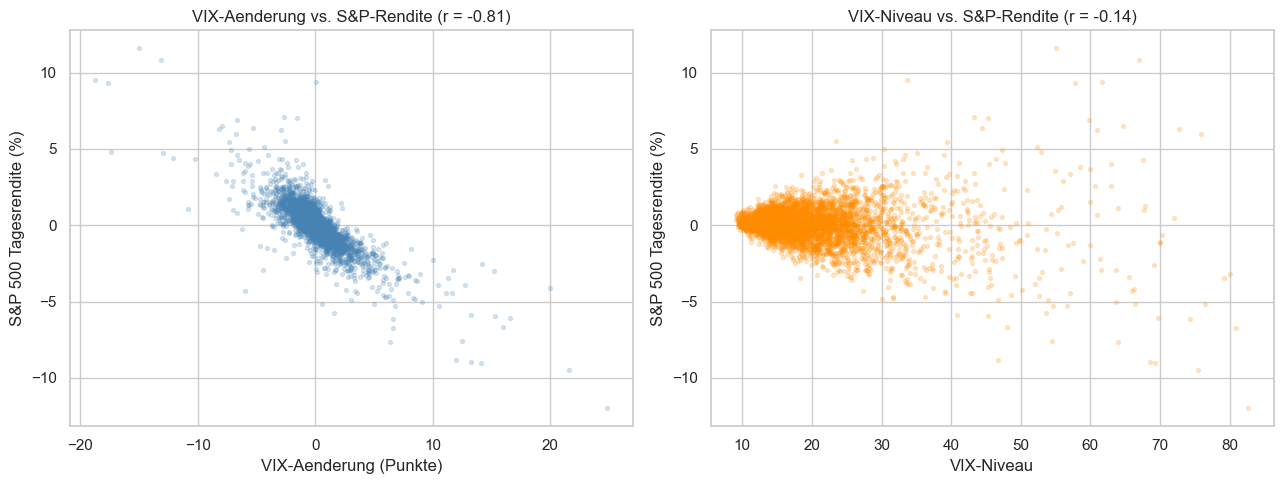

In [7]:
corr_change = df[["vix_change", "sp500_return"]].corr().iloc[0, 1]
corr_level = df[["vix_close", "sp500_return"]].corr().iloc[0, 1]
print(f"Korrelation VIX-Tagesaenderung vs. S&P-500-Tagesrendite: {corr_change:.3f}")
print(f"Korrelation VIX-Niveau vs. S&P-500-Tagesrendite: {corr_level:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["vix_change"], df["sp500_return"], alpha=0.2, s=8, color="steelblue")
axes[0].set_xlabel("VIX-Aenderung (Punkte)")
axes[0].set_ylabel("S&P 500 Tagesrendite (%)")
axes[0].set_title(f"VIX-Aenderung vs. S&P-Rendite (r = {corr_change:.2f})")

axes[1].scatter(df["vix_close"], df["sp500_return"], alpha=0.2, s=8, color="darkorange")
axes[1].set_xlabel("VIX-Niveau")
axes[1].set_ylabel("S&P 500 Tagesrendite (%)")
axes[1].set_title(f"VIX-Niveau vs. S&P-Rendite (r = {corr_level:.2f})")

plt.tight_layout()
plt.show()

**Ergebnis:** Die tägliche VIX-Veränderung ist stark invers mit der
S&P-500-Tagesrendite korreliert (r = −0,815) – steigt der VIX deutlich,
fällt der Index am selben Tag fast immer. Das reine VIX-Niveau sagt dagegen
kaum etwas über die Tagesrendite aus (r = −0,143).

**Praxisrelevanz für das Ampelsystem:** Der VIX eignet sich als
Zustandsindikator („wie angespannt ist der Markt“), nicht als Renditeprognose
(„steigt oder fällt der Markt heute“). Rot heißt „erhöhte Vorsicht“, nicht
„der Markt fällt heute“ – so sollte die Morgenroutine kommuniziert werden.


### 4.3 H3 – Volatility Clustering (Autokorrelation)

**Hypothese:** Der VIX zeigt Volatility Clustering, d. h. hohe bzw. niedrige
Werte treten in Clustern auf statt zufällig zu springen. Gemessen wird die
Autokorrelation des VIX-Niveaus für Lags von 1 bis 20 Handelstagen – relevant
für die Stabilität einer täglichen Ampel.


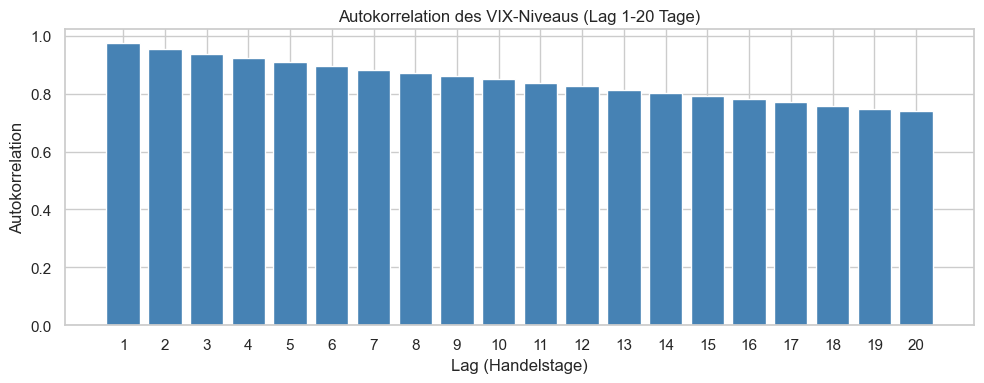

Autokorrelation Lag 1 (Vortag): 0.974
Autokorrelation Lag 5 (Vorwoche): 0.909


In [8]:
from pandas.plotting import autocorrelation_plot

lags = range(1, 21)
autocorrs = [df["vix_close"].autocorr(lag) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lags, autocorrs, color="steelblue")
ax.set_xlabel("Lag (Handelstage)")
ax.set_ylabel("Autokorrelation")
ax.set_title("Autokorrelation des VIX-Niveaus (Lag 1-20 Tage)")
ax.set_xticks(list(lags))
plt.tight_layout()
plt.show()

print(f"Autokorrelation Lag 1 (Vortag): {df['vix_close'].autocorr(1):.3f}")
print(f"Autokorrelation Lag 5 (Vorwoche): {df['vix_close'].autocorr(5):.3f}")

**Ergebnis:** Die Autokorrelation des VIX ist sowohl auf Tages- (Lag 1: 0,974)
als auch auf Wochensicht (Lag 5: 0,909) extrem hoch. Der VIX ist damit
ausgeprägt träge: ein hoher Wert heute macht einen hohen Wert morgen sehr
wahrscheinlich.

**Praxisrelevanz für das Ampelsystem:** Diese Trägheit ist für eine tägliche
Ampel ein Vorteil – die Farbe springt bei reiner Schwellenwert-Logik nicht
ständig hin und her („flackert“ nicht), sondern entwickelt sich stabil über
mehrere Tage. Das erhöht Glaubwürdigkeit und Akzeptanz des Signals.


### 4.4 H4 – Verteilung des VIX und Ampel-Schwellenwerte

**Hypothese:** Anhand der historischen Verteilung (Quantile) lassen sich
plausible Schwellenwerte für Grün/Gelb/Rot ableiten. Geprüft wird, wie gut
die Faustregel-Schwellen 20/30 zur tatsächlichen Verteilung passen und welcher
Anteil der Handelstage in welche Ampelphase fällt.


VIX-Quantile:
0.50    17.50
0.70    21.39
0.75    22.70
0.80    24.29
0.90    29.11
0.95    35.29
0.99    56.51
Name: vix_close, dtype: float64


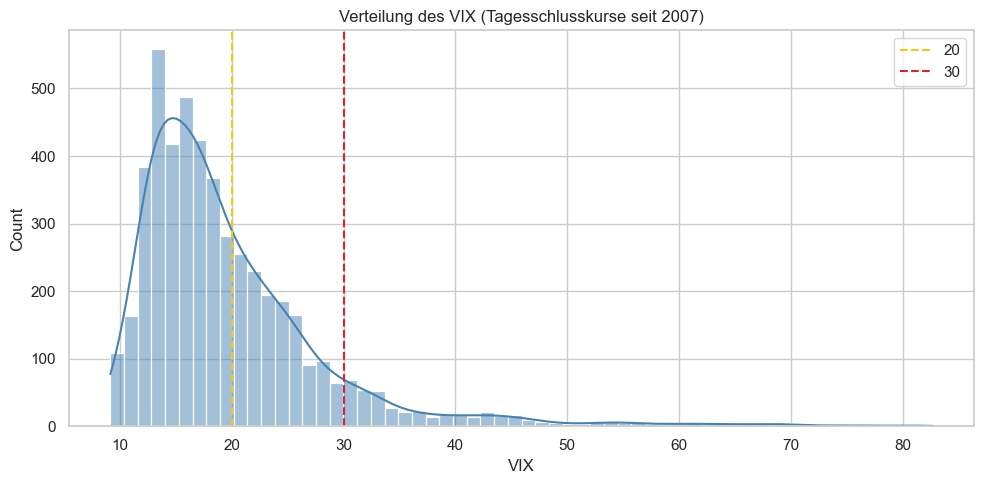

Gruen (<20): 64.1% der Handelstage
Gelb (20-30): 26.8% der Handelstage
Rot (>30): 9.1% der Handelstage


In [9]:
quantiles = df["vix_close"].quantile([0.5, 0.7, 0.75, 0.8, 0.9, 0.95, 0.99])
print("VIX-Quantile:")
print(quantiles.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["vix_close"], bins=60, kde=True, ax=ax, color="steelblue")
ax.axvline(20, color=COLOR_YELLOW, linestyle="--", label="20")
ax.axvline(30, color=COLOR_RED, linestyle="--", label="30")
ax.set_title("Verteilung des VIX (Tagesschlusskurse seit 2007)")
ax.set_xlabel("VIX")
ax.legend()
plt.tight_layout()
plt.show()

for low, high, label in [(0, 20, "Gruen (<20)"), (20, 30, "Gelb (20-30)"), (30, np.inf, "Rot (>30)")]:
    share = ((df["vix_close"] >= low) & (df["vix_close"] < high)).mean() * 100
    print(f"{label}: {share:.1f}% der Handelstage")

**Ergebnis:** Die VIX-Verteilung ist stark rechtsschief (Median 17,5 unter
Mittelwert 19,8). Mit den Faustregel-Schwellen 20/30 wäre der Markt an 64,1 %
der Tage grün, an 26,8 % gelb und an 9,1 % rot. Die Perzentile
(50/75/90/95 = 17,5/22,7/29,1/35,3) stützen diese Schwellen.

**Praxisrelevanz für das Ampelsystem:** Die Verteilung passt intuitiv zu
einem Gesundheitscheck: überwiegend unauffällig, gelegentlich auffällig,
selten kritisch. Der Rot-Anteil von 9,1 % ist ein Richtwert dafür, wie oft
die Routine Alarm schlagen würde – wichtig, um die Nutzerin nicht durch zu
häufige Warnungen abzustumpfen („Alarm-Fatigue“).


### 4.5 H5 – Dauer der Ampelphasen

**Hypothese:** Mit den Faustregel-Schwellen 20/30 wird jeder Handelstag in
Grün/Gelb/Rot klassifiziert; anschließend werden zusammenhängende Phasen
identifiziert und ihre Dauer ausgewertet – wichtig, um einzuschätzen, ob die
Ampel stabil genug für eine tägliche Routine ist.


In [10]:
def ampel(vix_value: float) -> str:
    if vix_value < 20:
        return "gruen"
    elif vix_value < 30:
        return "gelb"
    return "rot"

df["ampel"] = df["vix_close"].apply(ampel)

# zusammenhaengende Phasen identifizieren
phase_id = (df["ampel"] != df["ampel"].shift()).cumsum().rename("phase_id")
phases = df.groupby(phase_id).agg(
    ampel=("ampel", "first"),
    start=("ampel", lambda s: s.index[0]),
    ende=("ampel", lambda s: s.index[-1]),
    dauer_tage=("ampel", "size"),
)

print("Anzahl Phasenwechsel gesamt:", len(phases))
print("\
Durchschnittliche Phasendauer (Handelstage) je Ampelfarbe:")
print(phases.groupby("ampel")["dauer_tage"].describe()[["count", "mean", "50%", "max"]])

print("\
Die 5 laengsten Rot-Phasen:")
print(phases[phases["ampel"] == "rot"].sort_values("dauer_tage", ascending=False).head())

Anzahl Phasenwechsel gesamt: 404
Durchschnittliche Phasendauer (Handelstage) je Ampelfarbe:
       count       mean  50%    max
ampel                              
gelb   201.0   6.567164  2.0   80.0
gruen  150.0  21.053333  4.0  312.0
rot     53.0   8.471698  2.0  170.0
Die 5 laengsten Rot-Phasen:
         ampel      start       ende  dauer_tage
phase_id                                        
33         rot 2008-09-15 2009-05-18         170
101        rot 2011-08-04 2011-10-13          50
230        rot 2020-02-27 2020-05-07          50
109        rot 2011-11-09 2011-11-29          14
236        rot 2020-06-11 2020-06-30          14


**Ergebnis:** Seit 2007 gab es 404 Phasenwechsel. Rot-Phasen sind meist kurz
(Median 2 Handelstage), können in echten Krisen aber Monate dauern (längste
Phase 170 Tage, Finanzkrise 2008/09). Mittelwert (8,47) und Median (2) klaffen
stark auseinander – Rot ist meist ein kurzer Warnblinker, selten ein Dauerzustand.

**Praxisrelevanz für das Ampelsystem:** Ein einzelner Rot-Tag sollte keine
drastische Reaktion auslösen, da er statistisch meist nach 1–2 Tagen abklingt.
Eine Eskalationsregel („Rot an 3+ Tagen in Folge = erhöhte Warnstufe“) trennt
kurzfristiges Rauschen von echten Krisenphasen.


### 4.6 H6 – Neues 3-Monats-Hoch als Frühwarnsignal

**Hypothese:** Wenn der VIX ein neues 3-Monats-Hoch erreicht (höchster
Schlusskurs der vorangegangenen ca. 63 Handelstage), folgt in den nächsten
5 bzw. 10 Handelstagen überdurchschnittlich oft eine Phase mit VIX > 30. Die
Trefferquote wird mit der unbedingten Baseline verglichen.


In [11]:
# Rollierendes 3-Monats-Hoch VOR dem aktuellen Tag berechnen. shift(1) stellt sicher,
# dass der aktuelle Tag selbst nicht im Vergleichsfenster enthalten ist (kein Blick in die Zukunft).
WINDOW_3M = 63
rolling_high_3m = df["vix_close"].shift(1).rolling(WINDOW_3M).max()

# Signaltage: aktueller Schlusskurs liegt ueber dem rollierenden 3-Monats-Hoch
new_3m_high = df["vix_close"] > rolling_high_3m
print(f"Anzahl Signaltage (neues 3-Monats-Hoch): {int(new_3m_high.sum())}")

hit_rate_5 = forward_hit_rate(new_3m_high, horizon=5)
hit_rate_10 = forward_hit_rate(new_3m_high, horizon=10)
baseline_5 = forward_hit_rate(ALL_DAYS, horizon=5)
baseline_10 = forward_hit_rate(ALL_DAYS, horizon=10)

print(f"Trefferquote nach Signal, 5 Tage:  {hit_rate_5:.1%}  (Baseline: {baseline_5:.1%})")
print(f"Trefferquote nach Signal, 10 Tage: {hit_rate_10:.1%}  (Baseline: {baseline_10:.1%})")

Anzahl Signaltage (neues 3-Monats-Hoch): 153
Trefferquote nach Signal, 5 Tage:  39.2%  (Baseline: 12.3%)
Trefferquote nach Signal, 10 Tage: 41.8%  (Baseline: 15.2%)


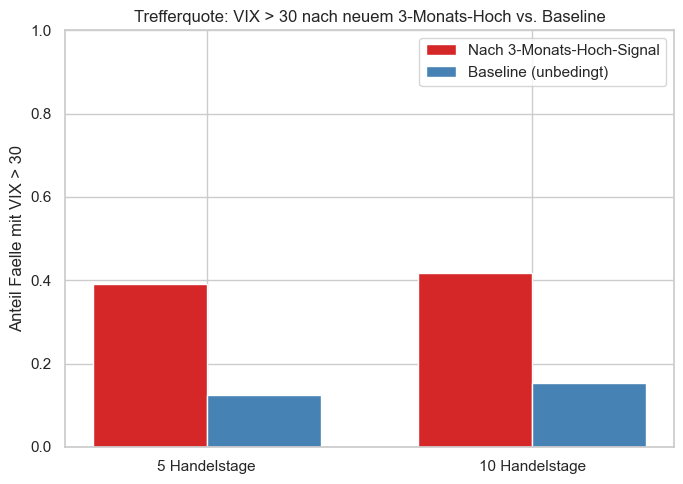

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["5 Handelstage", "10 Handelstage"]
signal_rates = [hit_rate_5, hit_rate_10]
baseline_rates = [baseline_5, baseline_10]
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width / 2, signal_rates, width, label="Nach 3-Monats-Hoch-Signal", color=COLOR_RED)
ax.bar(x + width / 2, baseline_rates, width, label="Baseline (unbedingt)", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel(f"Anteil Faelle mit VIX > {VIX_THRESHOLD_ROT}")
ax.set_ylim(0, 1)
ax.set_title("Trefferquote: VIX > 30 nach neuem 3-Monats-Hoch vs. Baseline")
ax.legend()
plt.tight_layout()
plt.show()

**Ergebnis:** Über den Beobachtungszeitraum gab es 153 neue 3-Monats-Hochs.
Nach einem solchen Signal lag der VIX in 39,2 % (5 Tage) bzw. 41,8 % (10 Tage)
der Fälle mindestens einmal über 30 – gegenüber einer Baseline von
12,3 % / 15,2 %. Das Signal erhöht die Trefferquote also um etwa den Faktor 3,
bleibt mit ~40 % aber ein Minderheits-Ereignis.

**Praxisrelevanz für das Ampelsystem:** Ein neues 3-Monats-Hoch eignet sich
als zusätzliches „Vorsicht“-Flag, das bereits vor Erreichen der Rot-Schwelle
anschlägt – etwa als kleines Warnsymbol neben der Hauptampel, ohne deren Farbe
selbst zu verändern. Hinweis: Da Anstiege oft mehrere Tage in Folge neue Hochs
erzeugen, sind die Signaltage nicht vollständig unabhängig voneinander.


### 4.7 H7 – „3-Punkte-Umkehr“ als Beruhigungssignal

**Hypothese:** An Tagen mit Open ≥ 20 UND Intraday-High > Open UND
(Intraday-High − Close) ≥ 3 schießt der VIX im Tagesverlauf nach oben, gibt
den Anstieg bis Handelsschluss aber größtenteils wieder ab. Geprüft wird per
Event-Study, ob der VIX an den 5 Folgetagen im Schnitt fällt (= Beruhigung).


In [13]:
# Signal-Definition: ausgepraegte Intraday-Umkehr im VIX
#   - Open >= 20            -> Markt startet bereits angespannt
#   - High > Open            -> im Tagesverlauf zieht der VIX weiter an
#   - (High - Close) >= 3    -> der Tag schliesst aber mindestens 3 Punkte unter dem Hoch
vix_ohlc = vix[["Open", "High", "Low", "Close"]].reindex(df.index)

reversal_signal = (
    (vix_ohlc["Open"] >= 20)
    & (vix_ohlc["High"] > vix_ohlc["Open"])
    & ((vix_ohlc["High"] - vix_ohlc["Close"]) >= 3)
)
signal_dates = df.index[reversal_signal.values]
print(f"Anzahl '3-Punkte-Umkehr'-Signale: {len(signal_dates)}")

# VIX-Entwicklung an den 5 Folgetagen, relativ zum Schlusskurs des Signaltags
HORIZON_H2 = 5
vix_close_values = df["vix_close"]
paths = []
for date in signal_dates:
    pos = df.index.get_loc(date)
    if pos + HORIZON_H2 >= len(df):
        continue  # nicht genug Folgetage vorhanden
    base = vix_close_values.iloc[pos]
    path = vix_close_values.iloc[pos : pos + HORIZON_H2 + 1].values - base
    paths.append(path)
paths = np.array(paths)

mean_path = paths.mean(axis=0)
median_path = np.median(paths, axis=0)
share_falling = (paths[:, -1] < 0).mean()

print(f"Auswertbare Signale: {len(paths)}")
print(f"Durchschnittliche VIX-Aenderung nach {HORIZON_H2} Tagen: {mean_path[-1]:+.2f} Punkte")
print(f"Median VIX-Aenderung nach {HORIZON_H2} Tagen:            {median_path[-1]:+.2f} Punkte")
print(f"Anteil Faelle mit niedrigerem VIX nach {HORIZON_H2} Tagen: {share_falling:.1%}")

Anzahl '3-Punkte-Umkehr'-Signale: 272
Auswertbare Signale: 272
Durchschnittliche VIX-Aenderung nach 5 Tagen: -1.51 Punkte
Median VIX-Aenderung nach 5 Tagen:            -2.02 Punkte
Anteil Faelle mit niedrigerem VIX nach 5 Tagen: 67.3%


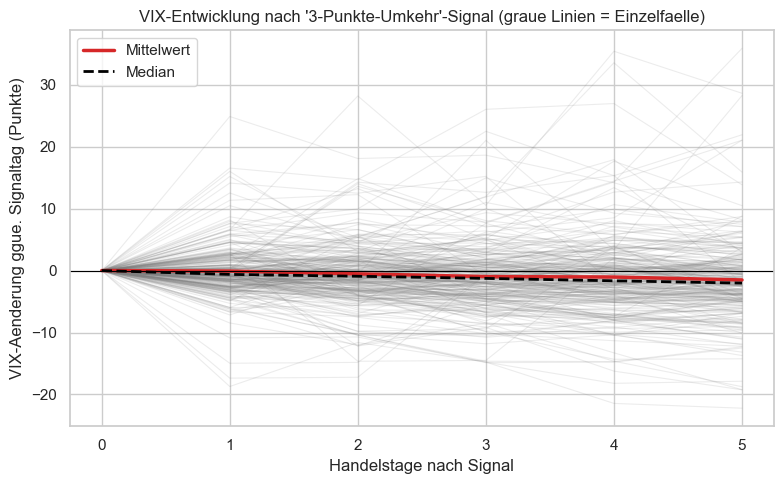

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
days = np.arange(0, HORIZON_H2 + 1)
for path in paths:
    ax.plot(days, path, color="grey", alpha=0.15, linewidth=0.8)
ax.plot(days, mean_path, color=COLOR_RED, linewidth=2.5, label="Mittelwert")
ax.plot(days, median_path, color="black", linewidth=2, linestyle="--", label="Median")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Handelstage nach Signal")
ax.set_ylabel("VIX-Aenderung ggue. Signaltag (Punkte)")
ax.set_title("VIX-Entwicklung nach '3-Punkte-Umkehr'-Signal (graue Linien = Einzelfaelle)")
ax.legend()
plt.tight_layout()
plt.show()

**Ergebnis:** Von 272 „3-Punkte-Umkehr“-Signalen fiel der VIX in 67,3 % der
Fälle innerhalb von 5 Handelstagen unter den Stand des Signaltags, im Schnitt
um 1,51 Punkte (Median −2,02). Die Beruhigungs-Hypothese wird tendenziell
bestätigt (rund zwei von drei Fällen), ist aber kein Automatismus – in knapp
einem Drittel der Fälle setzt sich der Anstieg fort.

**Praxisrelevanz für das Ampelsystem:** Das Signal eignet sich als
Entwarnungs-Hinweis innerhalb einer Gelb-/Rot-Phase („mögliche nahende
Beruhigung, historisch ca. 2 von 3 Fällen“) – es hilft, zwischen „Lage
verschärft sich“ und „Lage könnte sich entspannen“ zu unterscheiden, ohne
einen neuen Ampelzustand zu erzeugen.


### 4.8 H8 – VIX-Schwellenwerte anhand Verteilung und Stressphasen

**Hypothese:** Der VIX hebt sich während bekannter Stressphasen ab einem
bestimmten Niveau sichtbar vom Normalzustand ab. Verglichen werden die
Perzentile der Gesamtverteilung (50/75/90/95) mit Median, Minimum und Maximum
des VIX innerhalb und außerhalb der Krisenphasen, um die Gelb-/Rot-Schwellen
datenbasiert zu validieren.


In [15]:
percentiles_h3 = df["vix_close"].quantile([0.50, 0.75, 0.90, 0.95])
print("VIX-Perzentile (gesamter Zeitraum):")
print(percentiles_h3.round(2))

# Boolesche Maske: Tag liegt innerhalb einer der definierten Stressphasen
in_crisis = pd.Series(False, index=df.index)
for start, end in crisis_periods.values():
    in_crisis |= (df.index >= start) & (df.index <= end)

print("\nVIX waehrend Stressphasen (Median / Min / Max):")
print(df.loc[in_crisis, "vix_close"].agg(["median", "min", "max"]).round(2))
print("\nVIX ausserhalb von Stressphasen (Median / Min / Max):")
print(df.loc[~in_crisis, "vix_close"].agg(["median", "min", "max"]).round(2))

VIX-Perzentile (gesamter Zeitraum):
0.50    17.50
0.75    22.70
0.90    29.11
0.95    35.29
Name: vix_close, dtype: float64

VIX waehrend Stressphasen (Median / Min / Max):
median    31.77
min       14.38
max       82.69
Name: vix_close, dtype: float64

VIX ausserhalb von Stressphasen (Median / Min / Max):
median    16.90
min        9.14
max       52.33
Name: vix_close, dtype: float64


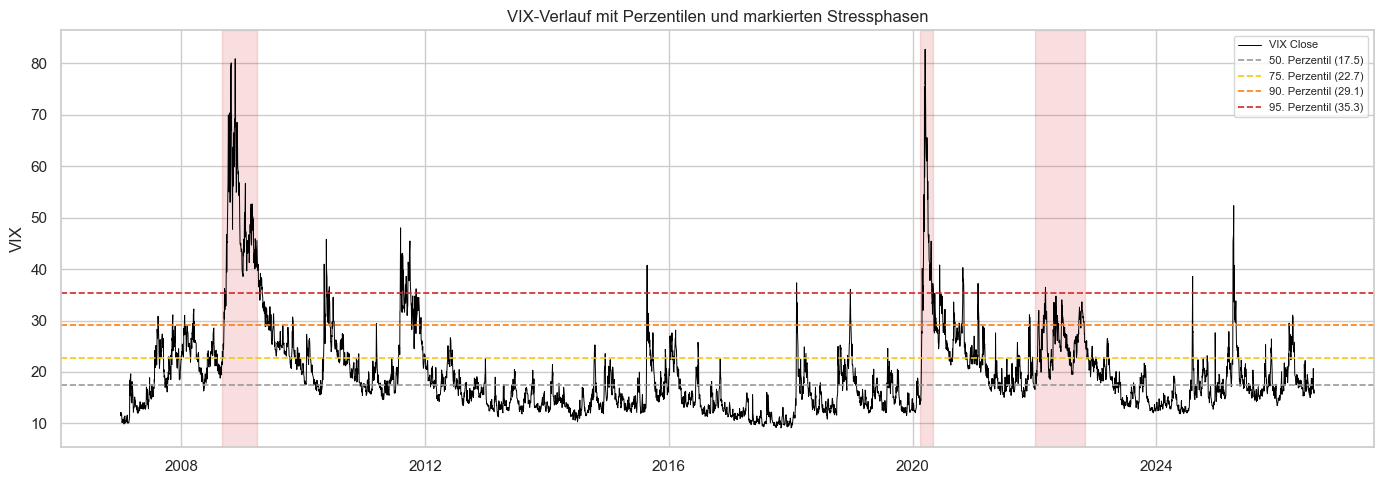

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["vix_close"], color="black", linewidth=0.7, label="VIX Close")

for label, (start, end) in crisis_periods.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=COLOR_RED, alpha=0.15)

percentile_colors = ["#999999", COLOR_YELLOW, "#ff7f0e", COLOR_RED]
for (q, val), color in zip(percentiles_h3.items(), percentile_colors):
    ax.axhline(val, linestyle="--", linewidth=1.2, color=color,
               label=f"{int(q * 100)}. Perzentil ({val:.1f})")

ax.set_title("VIX-Verlauf mit Perzentilen und markierten Stressphasen")
ax.set_ylabel("VIX")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

**Ergebnis:** Der Median-VIX während der markierten Stressphasen (31,77) liegt
nahe am 90. Perzentil der Gesamtverteilung (29,11) und deutlich über dem
75. Perzentil (22,70). Die Rot-Schwelle 30 ist damit datenbasiert gut gedeckt,
Gelb verortet sich im Bereich 75.–90. Perzentil (ca. 20–29). Der Min-Wert 14,38
innerhalb und Max-Wert 52,33 außerhalb der Phasen zeigen zugleich, dass die
grob nach Kalenderdatum definierten Fenster nicht trennscharf sind.

**Praxisrelevanz für das Ampelsystem:** Dies ist der zentrale Abschnitt zur
Kalibrierung: Er belegt datenbasiert, dass die Faustregel (Grün < 20,
Gelb 20–30, Rot > 30) nicht willkürlich ist, sondern sich an historischen
Perzentilen und realem Krisenverhalten orientiert.


### 4.9 H9 – Divergenz zum Index als Frühindikator

**Hypothese:** VIX und S&P 500 sind normalerweise invers korreliert (vgl. 4.2).
Ein hoher Anteil an Tagen mit untypischem Gleichlauf (beide steigen gleichzeitig)
in einem rollierenden Fenster könnte nachfolgende Marktturbulenzen ankündigen.
Als Turbulenz-Definition dient konsistent zu 4.6: VIX > 30 in den nächsten
10 Handelstagen.


In [17]:
# Tage, an denen S&P 500 UND VIX am selben Tag gleichzeitig gestiegen sind
co_up = (df["sp500_return"] > 0) & (df["vix_change"] > 0)

share_5d = co_up.rolling(5).mean()
share_10d = co_up.rolling(10).mean()

DIVERGENCE_THRESHOLD = 0.6
high_divergence_5d = share_5d > DIVERGENCE_THRESHOLD

print(f"Tage mit >{DIVERGENCE_THRESHOLD:.0%} Gleichlauf im 5-Tage-Fenster: "
      f"{int(high_divergence_5d.sum())} von {int(share_5d.notna().sum())} "
      f"({high_divergence_5d.mean():.1%})")

# Turbulenz-Wahrscheinlichkeit nach Divergenz-Signal vs. Baseline (baseline_10 aus Abschnitt 9.1,
# identische Definition: VIX > 30 in den naechsten 10 Handelstagen)
turbulence_after_divergence = forward_hit_rate(high_divergence_5d, horizon=10)

print(f"P(VIX > {VIX_THRESHOLD_ROT} in den naechsten 10 Tagen | Divergenz > {DIVERGENCE_THRESHOLD:.0%}): "
      f"{turbulence_after_divergence:.1%}")
print(f"P(VIX > {VIX_THRESHOLD_ROT} in den naechsten 10 Tagen), Baseline: {baseline_10:.1%}")

Tage mit >60% Gleichlauf im 5-Tage-Fenster: 5 von 4923 (0.1%)
P(VIX > 30 in den naechsten 10 Tagen | Divergenz > 60%): 0.0%
P(VIX > 30 in den naechsten 10 Tagen), Baseline: 15.2%


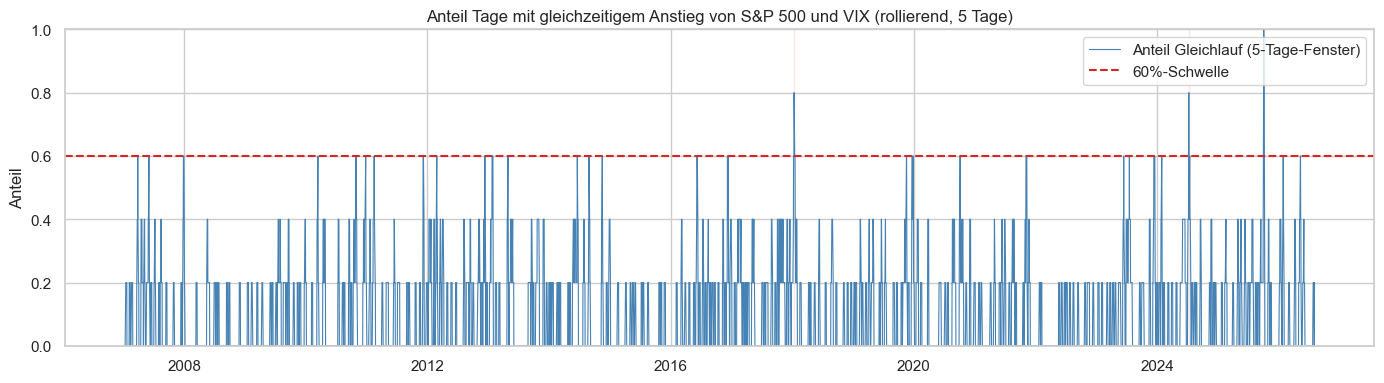

In [18]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, share_5d, color="steelblue", linewidth=0.8, label="Anteil Gleichlauf (5-Tage-Fenster)")
ax.axhline(DIVERGENCE_THRESHOLD, color=COLOR_RED, linestyle="--", label=f"{DIVERGENCE_THRESHOLD:.0%}-Schwelle")
ax.fill_between(df.index, 0, 1, where=high_divergence_5d.fillna(False).values, color=COLOR_RED, alpha=0.1)
ax.set_ylim(0, 1)
ax.set_title("Anteil Tage mit gleichzeitigem Anstieg von S&P 500 und VIX (rollierend, 5 Tage)")
ax.set_ylabel("Anteil")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Ergebnis:** Ein gleichzeitiger Anstieg von S&P 500 und VIX an mindestens
60 % der Tage eines 5-Tage-Fensters ist mit 5 von 4.923 Fenstern (0,1 %)
extrem selten. In diesen wenigen Fällen folgte in keinem einzigen (0,0 %)
innerhalb von 10 Tagen eine Rot-Phase (Baseline 15,2 %). In dieser strengen
Form wird die Hypothese nicht gestützt – mit nur 5 Fällen ist die Stichprobe
jedoch statistisch nicht belastbar.

**Praxisrelevanz für das Ampelsystem:** Vor einer Aufnahme in die Ampel muss
die Definition gelockert und mit mehr Fällen getestet werden – genau das
leistet die folgende Varianten-Analyse.


**Fortsetzung – Robustheitsprüfung der Divergenz-Parameter:** Da die
Original-Definition nur 5 Signale liefert, werden drei Stellschrauben
systematisch variiert (Fenster 5/10/20 Tage, Schwelle 60 %/20 %, Anstiegstag
Index-Rendite > 0 % vs. ≥ 0,25 %), sonst bleibt die Logik identisch. Die
Rendite-Schwelle von 0,25 % ist bewusst knapp oberhalb des Rauschens gewählt
(≈ 0,2 Standardabweichungen der Tagesrendite von rund 1,24 %) und filtert
Mini-/Nulllinien-Bewegungen heraus, ohne echte Aufwärtstage auszuschließen.


In [19]:
# Wiederverwendbare Funktion fuer die Divergenz-Varianten.
# Sie kapselt exakt die Logik aus Abschnitt 9.4, macht aber Fenstergroesse,
# Anteils-Schwelle und die Mindest-Tagesrendite fuer einen "Anstiegstag" variabel.
variant_results = {}

# Original-Variante aus 9.4 zum Vergleich registrieren (Werte stammen aus dem obigen Block)
variant_results["Original (5T / 60% / >0%)"] = {
    "fenster": 5, "schwelle": 0.60, "rendite_min": 0.0,
    "n_signale": int(high_divergence_5d.sum()),
    "n_fenster": int(share_5d.notna().sum()),
    "trefferquote": turbulence_after_divergence,
}


def run_divergence_variant(name, window, threshold, ret_min):
    """Fuehrt die Divergenz-Analyse aus 9.4 mit variablen Parametern aus,
    speichert die Kennzahlen in variant_results und plottet den rollierenden
    Gleichlauf-Anteil. Rueckgabe: (share, high_div) fuer optionale Weiterverwendung."""
    # "Anstiegstag" = S&P-Rendite ueber Schwelle UND VIX am selben Tag gestiegen
    co_up_local = (df["sp500_return"] > ret_min) & (df["vix_change"] > 0)
    share = co_up_local.rolling(window).mean()
    high_div = share > threshold

    n_signal = int(high_div.sum())
    n_windows = int(share.notna().sum())
    hit = forward_hit_rate(high_div, horizon=10)

    variant_results[name] = {
        "fenster": window, "schwelle": threshold, "rendite_min": ret_min,
        "n_signale": n_signal, "n_fenster": n_windows, "trefferquote": hit,
    }

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df.index, share, color="steelblue", linewidth=0.8,
            label=f"Anteil Gleichlauf ({window}-Tage-Fenster)")
    ax.axhline(threshold, color=COLOR_RED, linestyle="--", label=f"{threshold:.0%}-Schwelle")
    ax.fill_between(df.index, 0, 1, where=high_div.fillna(False).values,
                    color=COLOR_RED, alpha=0.1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{name}: Gleichlauf S&P 500 & VIX (Fenster={window}, "
                 f"Schwelle={threshold:.0%}, Index-Rendite>{ret_min:.2f}%)")
    ax.set_ylabel("Anteil")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    hit_str = f"{hit:.1%}" if pd.notna(hit) else "n/a (keine Signale)"
    print(f"Signale: {n_signal} von {n_windows} Fenstern ({n_signal / n_windows:.2%})")
    print(f"P(VIX > {VIX_THRESHOLD_ROT} in 10 Tagen | Signal): {hit_str}  "
          f"(Baseline: {baseline_10:.1%})")
    return share, high_div


#### Block 1 – Fenster 10 Tage (Schwelle 60 %, Rendite > 0 %)

Identische Logik wie im Original, nur das rollierende Fenster wird von 5 auf 10 Handelstage verlängert.


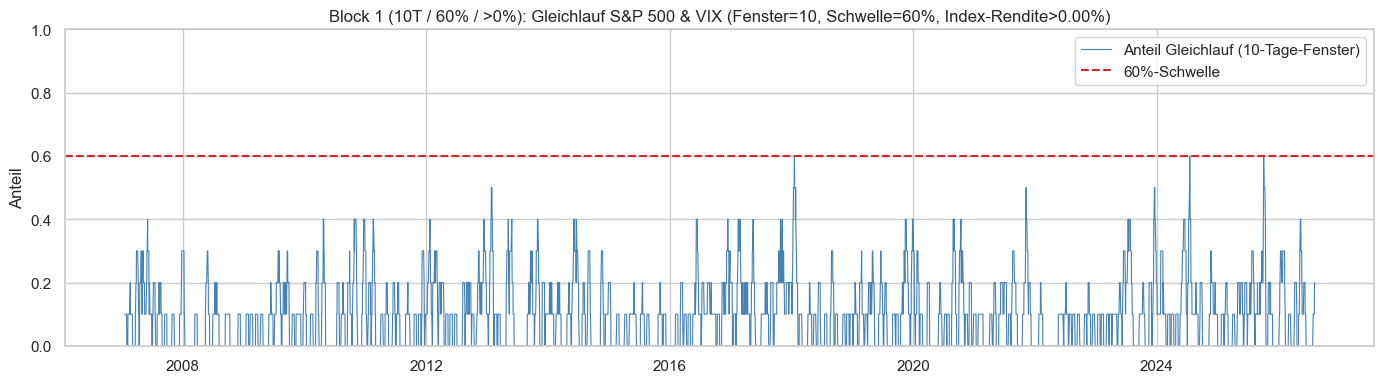

Signale: 0 von 4918 Fenstern (0.00%)
P(VIX > 30 in 10 Tagen | Signal): n/a (keine Signale)  (Baseline: 15.2%)


In [20]:
_ = run_divergence_variant("Block 1 (10T / 60% / >0%)", window=10, threshold=0.6, ret_min=0.0)


**Ergebnis:** Mit einem 10-Tage-Fenster tritt kein einziges Signal mehr auf
(0 von 4.918 Fenstern). Da ein gleichzeitiger Anstieg von S&P 500 und VIX
historisch nur an rund 20 % aller Tage vorkommt, ist ein Anteil von über 60 %
über zehn Tage praktisch unerreichbar.


#### Block 2 – Fenster 20 Tage (Schwelle 60 %, Rendite > 0 %)

Identische Logik, das Fenster wird auf 20 Handelstage verlängert.


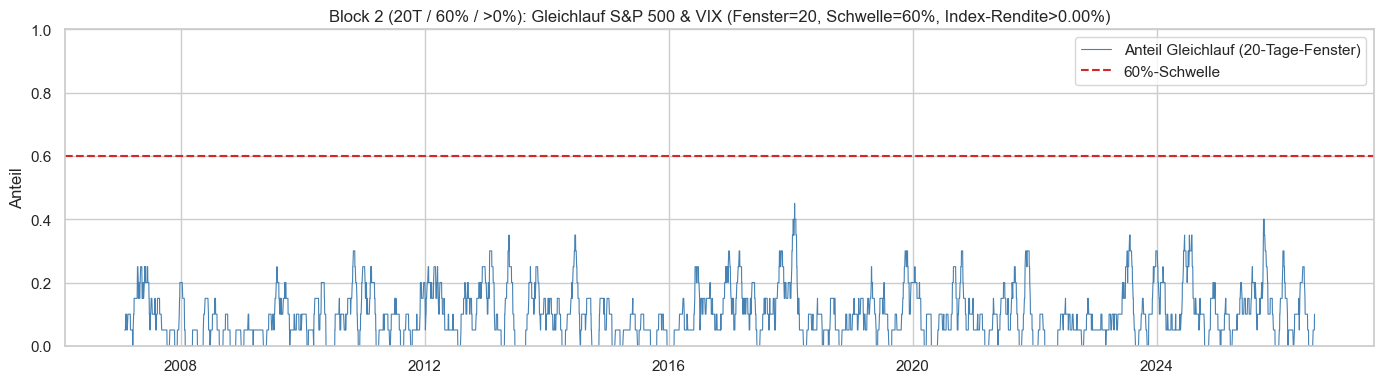

Signale: 0 von 4908 Fenstern (0.00%)
P(VIX > 30 in 10 Tagen | Signal): n/a (keine Signale)  (Baseline: 15.2%)


In [21]:
_ = run_divergence_variant("Block 2 (20T / 60% / >0%)", window=20, threshold=0.6, ret_min=0.0)


**Ergebnis:** Auch mit 20-Tage-Fenster bleibt die 60 %-Schwelle bei 0 Signalen
(von 4.908 Fenstern) völlig leer – über einen ganzen Handelsmonat einen
60-prozentigen Gleichlauf zu erreichen, ist im Beobachtungszeitraum nie
vorgekommen.


#### Block 3 – Anteils-Schwelle 20 % (Fenster 5 Tage, Rendite > 0 %)

Identische Logik, die Schwelle für „auffälligen Gleichlauf“ wird von 60 % auf 20 % gesenkt.


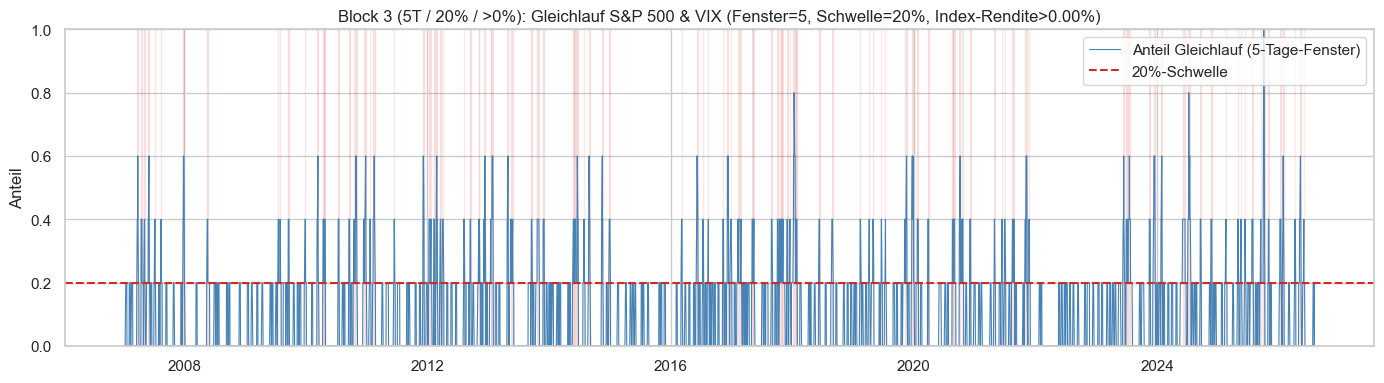

Signale: 471 von 4923 Fenstern (9.57%)
P(VIX > 30 in 10 Tagen | Signal): 6.2%  (Baseline: 15.2%)


In [22]:
_ = run_divergence_variant("Block 3 (5T / 20% / >0%)", window=5, threshold=0.2, ret_min=0.0)


**Ergebnis:** Das Absenken der Schwelle auf 20 % erzeugt mit 471 Signalen
(9,6 % aller Fenster) erstmals eine große Stichprobe. Die Trefferquote liegt
mit 6,2 % jedoch deutlich unter der Baseline von 15,2 %: kurzfristige
Gleichlauf-Cluster sind kein Turbulenz-Vorbote, sondern gehen tendenziell sogar
mit ruhigeren Folgephasen einher.


#### Block 4 – Anstiegstag = Index-Rendite mindestens 0,25 % (Fenster 5 Tage, Schwelle 60 %)

Identische Basis, aber ein Tag zählt nur als „gemeinsamer Anstiegstag“, wenn die S&P-500-Tagesrendite mindestens 0,25 % beträgt.


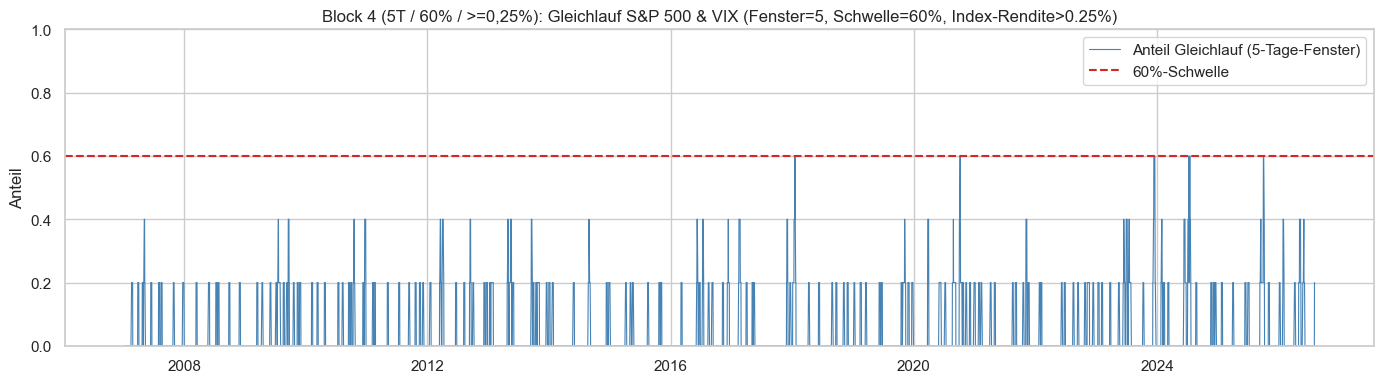

Signale: 0 von 4923 Fenstern (0.00%)
P(VIX > 30 in 10 Tagen | Signal): n/a (keine Signale)  (Baseline: 15.2%)


In [23]:
_ = run_divergence_variant("Block 4 (5T / 60% / >=0,25%)", window=5, threshold=0.6, ret_min=0.25)


**Ergebnis:** Der zusätzliche Rendite-Filter reduziert die Zahl der
Anstiegstage weiter, sodass die ohnehin strenge 60 %-Schwelle im 5-Tage-Fenster
gar nicht mehr erreicht wird (0 Signale). Die Kombination aus hoher Schwelle
und Rendite-Filter ist damit zu restriktiv.


#### Block 5 – Kombination Fenster 10 Tage + Schwelle 20 % + Rendite ≥ 0,25 %

Kombiniert die Anpassungen aus Block 1, Block 3 und Block 4.


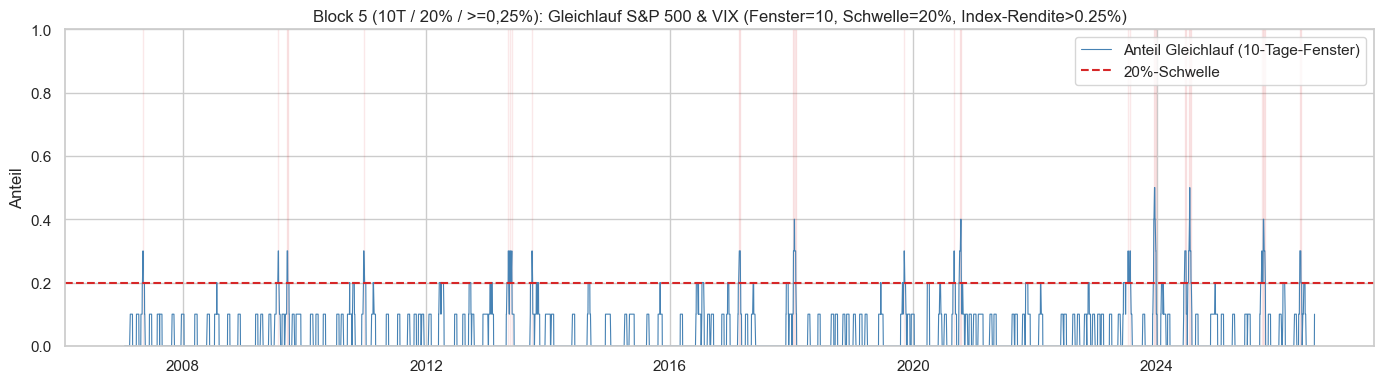

Signale: 88 von 4918 Fenstern (1.79%)
P(VIX > 30 in 10 Tagen | Signal): 11.4%  (Baseline: 15.2%)


In [24]:
_ = run_divergence_variant("Block 5 (10T / 20% / >=0,25%)", window=10, threshold=0.2, ret_min=0.25)


**Ergebnis:** Die Kombination liefert 88 Signale bei einer Trefferquote von
11,4 % – weiterhin unterhalb der Baseline von 15,2 %. Der Rendite-Filter hebt
die Trefferquote gegenüber Block 3 (6,2 %) zwar spürbar an, reicht aber noch
nicht für einen echten Mehrwert.


#### Block 6 – Kombination Fenster 20 Tage + Schwelle 20 % + Rendite ≥ 0,25 %

Kombiniert die Anpassungen aus Block 2, Block 3 und Block 4.


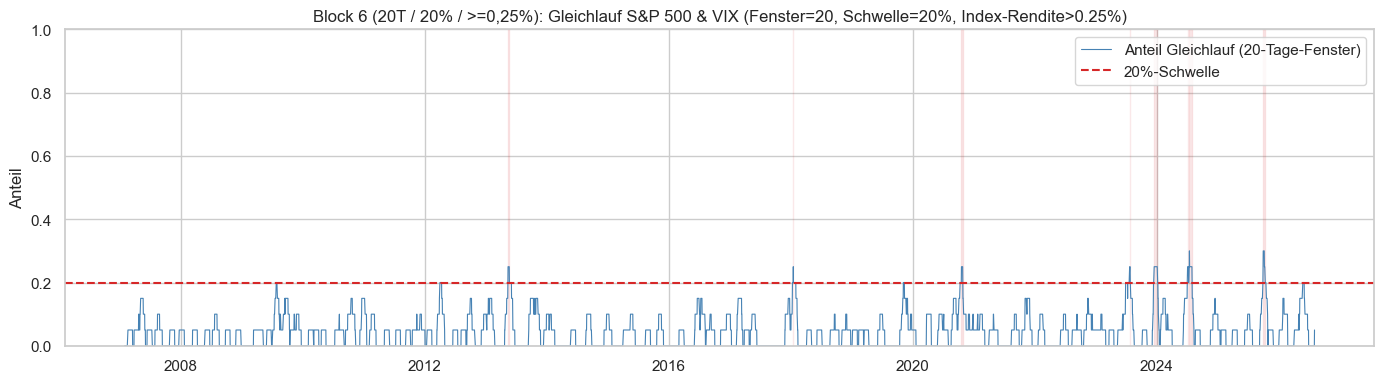

Signale: 56 von 4908 Fenstern (1.14%)
P(VIX > 30 in 10 Tagen | Signal): 25.0%  (Baseline: 15.2%)


In [25]:
_ = run_divergence_variant("Block 6 (20T / 20% / >=0,25%)", window=20, threshold=0.2, ret_min=0.25)


**Ergebnis:** Diese Variante ist die einzige, die die Baseline klar schlägt:
56 Signale bei einer Trefferquote von 25,0 % gegenüber 15,2 % (Faktor ~1,6).
Ein über einen vollen Handelsmonat anhaltender, substanzieller Gleichlauf
scheint tatsächlich ein struktureller Vorbote erhöhter Turbulenz zu sein – im
Gegensatz zum kurzfristigen Rauschen aus Block 3.


#### Zusammenfassende Übersicht aller 7 Varianten

Gegenüberstellung von Signalanzahl und Trefferquote je Parameterkombination.
Nur wenn die Trefferquote klar über der Baseline liegt UND genügend Signale
vorliegen, ist eine Variante als Frühindikator belastbar.


                               Fenster Schwelle Rendite-Min  Signale  Fenster (n) Trefferquote Baseline
Original (5T / 60% / >0%)            5      60%      >0.00%        5         4923         0.0%    15.2%
Block 1 (10T / 60% / >0%)           10      60%      >0.00%        0         4918          n/a    15.2%
Block 2 (20T / 60% / >0%)           20      60%      >0.00%        0         4908          n/a    15.2%
Block 3 (5T / 20% / >0%)             5      20%      >0.00%      471         4923         6.2%    15.2%
Block 4 (5T / 60% / >=0,25%)         5      60%      >0.25%        0         4923          n/a    15.2%
Block 5 (10T / 20% / >=0,25%)       10      20%      >0.25%       88         4918        11.4%    15.2%
Block 6 (20T / 20% / >=0,25%)       20      20%      >0.25%       56         4908        25.0%    15.2%


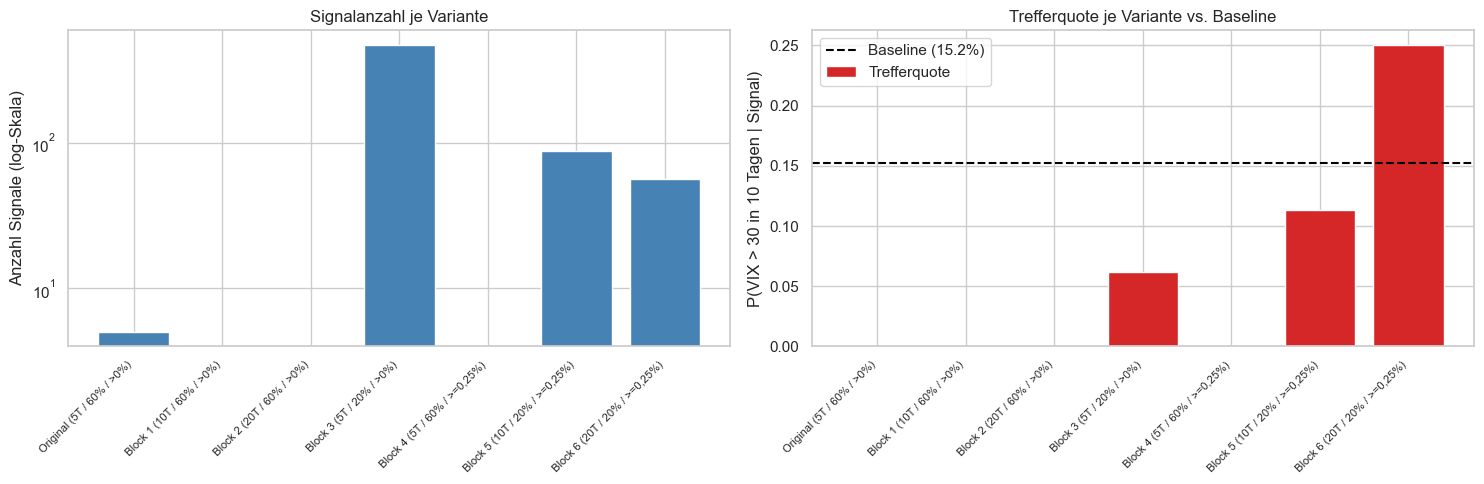

In [26]:
summary = pd.DataFrame(variant_results).T
summary = summary[["fenster", "schwelle", "rendite_min", "n_signale", "n_fenster", "trefferquote"]]
summary["fenster"] = summary["fenster"].astype(int)
summary["n_signale"] = summary["n_signale"].astype(int)
summary["n_fenster"] = summary["n_fenster"].astype(int)
summary["trefferquote"] = summary["trefferquote"].astype(float)

# Formatierte Anzeige-Tabelle
disp = summary.copy()
disp["schwelle"] = disp["schwelle"].map(lambda x: f"{x:.0%}")
disp["rendite_min"] = disp["rendite_min"].map(lambda x: f">{x:.2f}%")
disp["trefferquote"] = summary["trefferquote"].map(lambda x: f"{x:.1%}" if pd.notna(x) else "n/a")
disp["baseline"] = f"{baseline_10:.1%}"
disp = disp.rename(columns={
    "fenster": "Fenster", "schwelle": "Schwelle", "rendite_min": "Rendite-Min",
    "n_signale": "Signale", "n_fenster": "Fenster (n)", "trefferquote": "Trefferquote",
    "baseline": "Baseline",
})
print(disp.to_string())

# Visualisierung: Signalanzahl (log) und Trefferquote vs. Baseline
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
names = list(summary.index)
x = np.arange(len(names))

axes[0].bar(x, summary["n_signale"], color="steelblue")
axes[0].set_yscale("log")
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Anzahl Signale (log-Skala)")
axes[0].set_title("Signalanzahl je Variante")

hit_vals = summary["trefferquote"].fillna(0).values
axes[1].bar(x, hit_vals, color=COLOR_RED, label="Trefferquote")
axes[1].axhline(baseline_10, color="black", linestyle="--", label=f"Baseline ({baseline_10:.1%})")
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("P(VIX > 30 in 10 Tagen | Signal)")
axes[1].set_title("Trefferquote je Variante vs. Baseline")
axes[1].legend()

plt.tight_layout()
plt.show()


**Ergebnis der Varianten-Analyse:** Es zeigt sich ein klarer Trade-off zwischen
Signalanzahl und Trennschärfe. Die strengen 60 %-Varianten (Original sowie
Block 1, 2 und 4) liefern 0–5 Signale und sind statistisch nicht auswertbar.
Das bloße Absenken der Schwelle (Block 3) erzeugt viele Signale, deren
Trefferquote (6,2 %) aber unter der Baseline liegt. Erst die Kombination aus
langem Fenster, niedriger Schwelle und Rendite-Filter dreht das Bild: Block 6
(20 Tage / 20 % / ≥ 0,25 %) schlägt die Baseline als einzige klar (25,0 % vs.
15,2 %) und kommt als langsames, ergänzendes Zusatz-Warnsignal in Frage – nicht
als eigenständiger Auslöser.


## 5. Vertiefte Einzelbetrachtung

Die Hypothesenanalyse in Abschnitt 4 bewertet jedes Signal fuer sich. Dieser
Abschnitt hat einen gezielten, davon verschiedenen Zweck: Er **stellt die
ampel-relevanten Signale direkt gegenueber**, um ihre *Charakteristik* zu
vergleichen – insbesondere die Frage, welche Signale dem VIX-Anstieg
**vorlaufen** und welche eher **gleichlaufend** auf bereits erhoehtem Niveau
auftreten. Diese Unterscheidung ergibt sich erst aus der einheitlichen
Betrachtung mehrerer Signale mit demselben Kennzahlensatz und ist der eigentliche
Mehrwert dieses Abschnitts gegenueber der Einzelauswertung in Kapitel 4.

**Darstellung und methodische Abgrenzung:** Analog zur „Vertieften
Einzelbetrachtung“ (7.4) des SMA-Schwester-Notebooks wird je Signal eine
zweiteilige Grafik erstellt: oben der VIX-Verlauf mit farblich hinterlegten
Signaltagen, unten das **Vorwaerts-Profil** (Event-Study) – der gemittelte Pfad
der VIX-Aenderung in den Handelstagen nach dem Signal. Da dieses Notebook
explorativ ist und keine handelbare Strategie backtestet, tritt das
Vorwaerts-Profil an die Stelle der Equity-Kurve des Referenz-Notebooks. Die
verwendeten Kennzahlen-Entsprechungen:

| SMA-Notebook (7.4) | VIX-Entsprechung | Begruendung |
|---|---|---|
| Anteil ausgeschlossener Tage | Anteil Handelstage mit Signal | Beides misst die Haeufigkeit des markierten Zustands. |
| Gesamtrendite / CAGR | Mittl. VIX-Aenderung nach 5 / 10 Tagen | Typisches Ergebnis nach dem Signal: Beruhigung (fallend) vs. Eskalation (steigend). |
| Max Drawdown | Median max. VIX-Anstieg im Folgefenster | Beim VIX ist das Risiko ein Aufwaerts-Ausschlag. |
| (Signalguete) | Trefferquote VIX > 30 vs. Baseline | Prognostischer Mehrwert (vgl. 3.1). |

**Auswahl der Signale:** Verglichen werden drei Signale mit unterschiedlicher
Charakteristik: das **neue 3-Monats-Hoch** (H6), die **Divergenz Block 6** (H9)
sowie das **Rot-Regime** (VIX ≥ 30) als Basis-Ampelzustand. Die *3-Punkte-Umkehr*
(H7) wird hier nicht erneut einzeln dargestellt, da ihr Vorwaerts-Verhalten
bereits in Abschnitt 4.7 als eigene Event-Study analysiert wurde; in der
Gesamteinordnung unten wird sie dennoch beruecksichtigt.


### 5.1 Vorbereitung: Signal-Katalog und Hilfsfunktionen

Zunächst werden die vier Signalmasken einheitlich auf dem gemeinsamen
Handelskalender definiert (konsistent zu den Definitionen aus Abschnitt 4)
sowie zwei zusätzliche Plot-Farben ergänzt. Die Funktion
`vertiefte_einzelbetrachtung` kapselt die zweiteilige Darstellung und die
Kennzahlen-Berechnung.


In [27]:
# --- Zusätzliche Plot-Farben für die 2-Panel-Darstellung
COLOR_PRICE = "#0b0b0b"   # VIX-Kurve (neutral/dunkel)
COLOR_MUTED = "#898781"   # Einzelpfade im Vorwärtsprofil

# --- Signal-Katalog: die vier repräsentativen Signale aus Kapitel 4 ----------
# Alle Masken sind boolesche Series auf dem gemeinsamen Handelskalender (df.index).

# Signal 1: Neues 3-Monats-Hoch (vgl. 4.6) - höchster Schlusskurs der letzten 63 Tage
sig_3m_hoch = df["vix_close"] > df["vix_close"].shift(1).rolling(63).max()

# Signal 2: 3-Punkte-Umkehr (vgl. 4.7) - Intraday-Hochschuss mit Rücksetzer zum Close
_ohlc = vix[["Open", "High", "Low", "Close"]].reindex(df.index)
sig_umkehr = (
    (_ohlc["Open"] >= 20)
    & (_ohlc["High"] > _ohlc["Open"])
    & ((_ohlc["High"] - _ohlc["Close"]) >= 3)
)

# Signal 3: Divergenz-Variante Block 6 (vgl. 4.9) - belastbarste Parametrisierung
#           (20-Tage-Fenster, 20 %-Schwelle, Index-Anstieg >= 0,25 %)
_co_up = (df["sp500_return"] > 0.25) & (df["vix_change"] > 0)
sig_divergenz = _co_up.rolling(20).mean() > 0.20

# Signal 4: Rot-Regime (VIX >= 30, vgl. 4.4/4.5) - der Basis-Ampelzustand selbst.
#           Für die Vorwärtsbetrachtung werden die Eintrittstage (erster Tag einer
#           Rot-Phase) verwendet, um die extreme Überlappung aufeinanderfolgender
#           Rot-Tage zu vermeiden.
sig_rot = df["vix_close"] >= 30
sig_rot_eintritt = sig_rot & ~sig_rot.shift(1, fill_value=False)

print("Signal-Katalog erstellt:")
for _name, _maske in [("3-Monats-Hoch", sig_3m_hoch), ("3-Punkte-Umkehr", sig_umkehr),
                      ("Divergenz (Block 6)", sig_divergenz), ("Rot-Regime", sig_rot),
                      ("Rot-Eintritte", sig_rot_eintritt)]:
    print(f"  {_name:22s}: {int(_maske.sum()):4d} Tage")


Signal-Katalog erstellt:
  3-Monats-Hoch         :  153 Tage
  3-Punkte-Umkehr       :  272 Tage
  Divergenz (Block 6)   :   56 Tage
  Rot-Regime            :  449 Tage
  Rot-Eintritte         :   53 Tage


In [28]:
def vertiefte_einzelbetrachtung(name, phasen_maske, ereignis_maske=None,
                                horizon=10, titel=None, farbe=COLOR_RED):
    '''Zweiteilige Einzelbetrachtung eines Signals (analog zur SMA-Notebook-
    Systematik): oben der VIX-Verlauf mit farblich hinterlegten Signaltagen,
    darunter das gemittelte Vorwärtsprofil des VIX in den Tagen nach dem Signal
    (Event-Study). Gibt die Kennzahlen als dict zurück.'''
    titel = titel or name
    phasen = phasen_maske.reindex(df.index).fillna(False)
    ereignis = ereignis_maske if ereignis_maske is not None else phasen_maske
    ereignis = ereignis.reindex(df.index).fillna(False)

    vix_werte = df["vix_close"].values
    ereignis_idx = np.where(ereignis.values)[0]

    # Vorwärtsprofile relativ zum Signaltag + abgeleitete Kennzahlen
    pfade, max_anstiege = [], []
    treffer, gueltig = 0, 0
    for i in ereignis_idx:
        if i + horizon >= len(vix_werte):
            continue  # kein vollständiges Folgefenster mehr vorhanden
        basis = vix_werte[i]
        pfade.append(vix_werte[i : i + horizon + 1] - basis)
        nachfolger = vix_werte[i + 1 : i + 1 + horizon]
        gueltig += 1
        if nachfolger.max() > VIX_THRESHOLD_ROT:
            treffer += 1
        max_anstiege.append(nachfolger.max() - basis)
    pfade = np.array(pfade)
    mittel_pfad = pfade.mean(axis=0)
    median_pfad = np.median(pfade, axis=0)

    anteil_tage = phasen.mean()
    trefferquote = treffer / gueltig if gueltig else np.nan
    aenderung_5 = mittel_pfad[5] if horizon >= 5 else np.nan
    aenderung_10 = mittel_pfad[horizon]
    median_max_anstieg = float(np.median(max_anstiege)) if max_anstiege else np.nan

    # --- 2-Panel-Plot: oben VIX + Signalphasen, unten Vorwärtsprofil
    fig, (ax_vix, ax_fwd) = plt.subplots(2, 1, figsize=(12, 7))

    ax_vix.fill_between(df.index, 0, 1, where=phasen.values, color=farbe, alpha=0.15,
                        transform=ax_vix.get_xaxis_transform())
    ax_vix.plot(df.index, df["vix_close"], color=COLOR_PRICE, linewidth=0.8)
    ax_vix.axhline(VIX_THRESHOLD_ROT, color=COLOR_RED, linestyle="--", linewidth=1,
                   label=f"Rot-Schwelle ({VIX_THRESHOLD_ROT})")
    ax_vix.set_ylabel("VIX")
    ax_vix.set_title(f"{titel} – farblich hinterlegt: Signaltage")
    ax_vix.legend(loc="upper right")

    tage = np.arange(0, horizon + 1)
    for p in pfade:
        ax_fwd.plot(tage, p, color=COLOR_MUTED, alpha=0.12, linewidth=0.7)
    ax_fwd.plot(tage, mittel_pfad, color=farbe, linewidth=2.5, label="Mittelwert")
    ax_fwd.plot(tage, median_pfad, color="black", linewidth=2, linestyle="--", label="Median")
    ax_fwd.axhline(0, color="black", linewidth=0.8)
    ax_fwd.set_xlabel("Handelstage nach Signal")
    ax_fwd.set_ylabel("VIX-Änderung ggue. Signaltag (Punkte)")
    ax_fwd.set_title("Gemitteltes Vorwärtsprofil (graue Linien = Einzelfälle)")
    ax_fwd.legend(loc="upper left")

    fig.tight_layout()
    plt.show()

    print(f"Anteil Handelstage mit Signal:             {anteil_tage:.1%}  ({int(phasen.sum())} Tage)")
    print(f"Auswertbare Ereignisse (Vorwärtsprofil):   {gueltig}")
    print(f"Trefferquote VIX > {VIX_THRESHOLD_ROT} in {horizon} Tagen:         {trefferquote:.1%}  (Baseline: {baseline_10:.1%})")
    print(f"Mittl. VIX-Änderung nach 5 / {horizon} Tagen:     {aenderung_5:+.2f} / {aenderung_10:+.2f} Punkte")
    print(f"Median max. VIX-Anstieg im {horizon}-Tage-Fenster:  {median_max_anstieg:+.2f} Punkte")

    return {"name": name, "anteil_tage": anteil_tage, "trefferquote": trefferquote,
            "aenderung_5": aenderung_5, "aenderung_10": aenderung_10,
            "median_max_anstieg": median_max_anstieg, "n_ereignisse": gueltig}


### 5.2 Einzelbetrachtung der repräsentativen Signale

Für jedes Signal folgen die zweiteilige Grafik, die Kennzahlen sowie eine
kurze Ergebnis- und Praxiseinordnung.


#### Signal 1 – Neues 3-Monats-Hoch (H6)


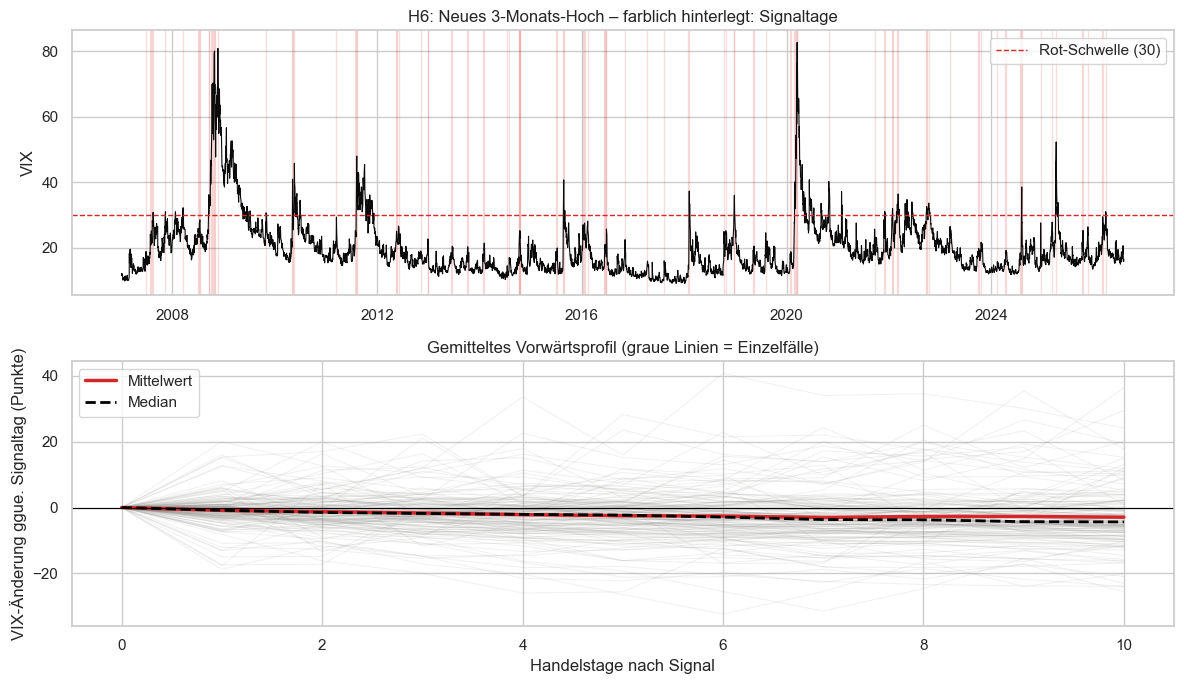

Anteil Handelstage mit Signal:             3.1%  (153 Tage)
Auswertbare Ereignisse (Vorwärtsprofil):   153
Trefferquote VIX > 30 in 10 Tagen:         41.8%  (Baseline: 15.2%)
Mittl. VIX-Änderung nach 5 / 10 Tagen:     -2.47 / -2.92 Punkte
Median max. VIX-Anstieg im 10-Tage-Fenster:  +1.23 Punkte


In [29]:
res_3m = vertiefte_einzelbetrachtung(
    "3-Monats-Hoch", sig_3m_hoch, titel="H6: Neues 3-Monats-Hoch", farbe=COLOR_RED)


**Ergebnis:** Das Signal markiert 3,1 % der Handelstage (153 Ereignisse). Die
Trefferquote für VIX > 30 innerhalb von 10 Tagen liegt mit 41,8 % rund beim
Faktor 2,7 über der Baseline (15,2 %). Im Mittel *fällt* der VIX nach dem Signal
jedoch (−2,47 nach 5, −2,92 nach 10 Tagen), und der mediane maximale
Weiter-Anstieg ist mit +1,23 Punkten gering – ein neues 3-Monats-Hoch tritt oft
bereits auf erhöhtem Niveau auf, das anschließend eher mean-revertiert.

**Praxisrelevanz für das Ampelsystem:** Das Signal taugt als Frühwarn-Flag für
eine erhöhte Rot-Bereitschaft (in gut 40 % der Fälle wird die Rot-Schwelle
berührt), nicht aber als Vorbote einer massiven weiteren Eskalation – passend
zur Rolle als dezentes „Vorsicht“-Nebensignal neben der Hauptampel.

#### Signal 2 – Divergenz (Block 6, H9)


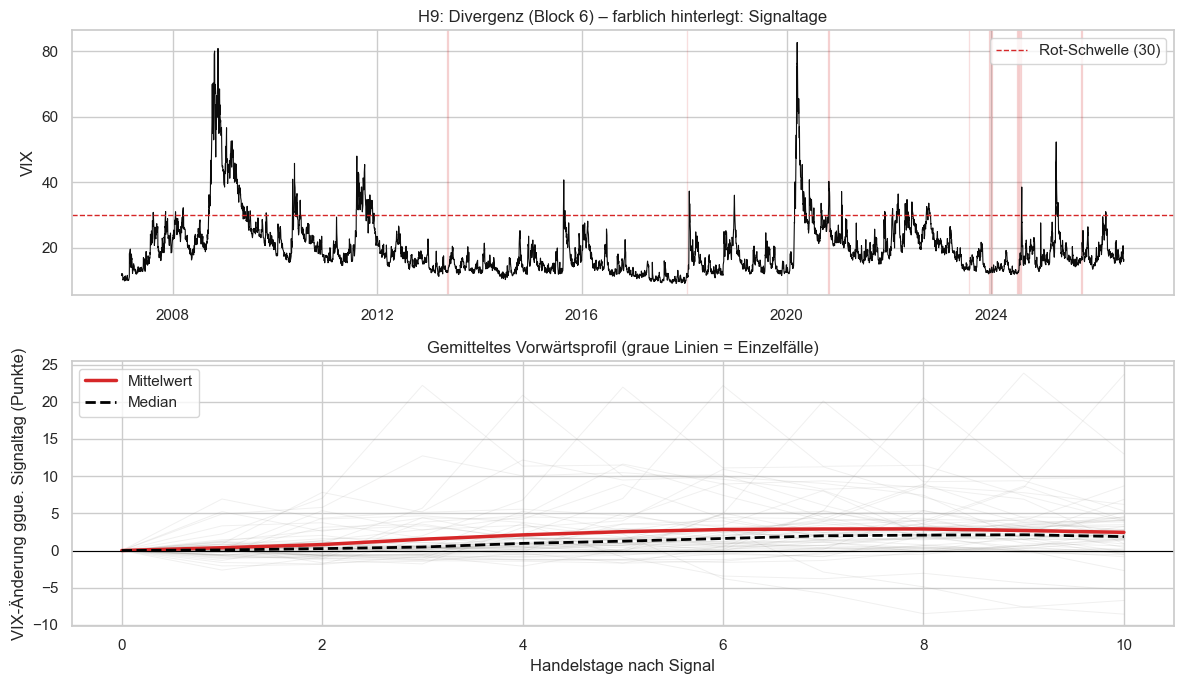

Anteil Handelstage mit Signal:             1.1%  (56 Tage)
Auswertbare Ereignisse (Vorwärtsprofil):   56
Trefferquote VIX > 30 in 10 Tagen:         25.0%  (Baseline: 15.2%)
Mittl. VIX-Änderung nach 5 / 10 Tagen:     +2.53 / +2.45 Punkte
Median max. VIX-Anstieg im 10-Tage-Fenster:  +4.09 Punkte


In [30]:
res_div = vertiefte_einzelbetrachtung(
    "Divergenz (Block 6)", sig_divergenz, titel="H9: Divergenz (Block 6)", farbe=COLOR_RED)


**Ergebnis:** Dieses Signal verhält sich als einziges qualitativ anders: Sein
Vorwärtsprofil *steigt* (+2,53 nach 5, +2,45 nach 10 Tagen), der mediane
maximale Anstieg ist mit +4,09 Punkten der größte aller vier Signale, und die
Trefferquote liegt mit 25,0 % klar über der Baseline (15,2 %). Bei nur 1,1 %
der Tage (56 Ereignisse) markiert es tatsächlich eine Phase *vor* dem Anstieg.

**Praxisrelevanz für das Ampelsystem:** Anders als die übrigen drei Signale,
die auf bereits erhöhtem Niveau auftreten und mean-revertieren, ist Block 6 ein
echter *vorlaufender* Frühindikator. Genau das macht ihn als ergänzendes
Warnsignal wertvoll – er kann anschlagen, bevor die Hauptampel auf Rot springt
(bei allerdings noch schmaler Datenbasis von 56 Fällen).

#### Signal 3 – Rot-Regime (VIX ≥ 30)


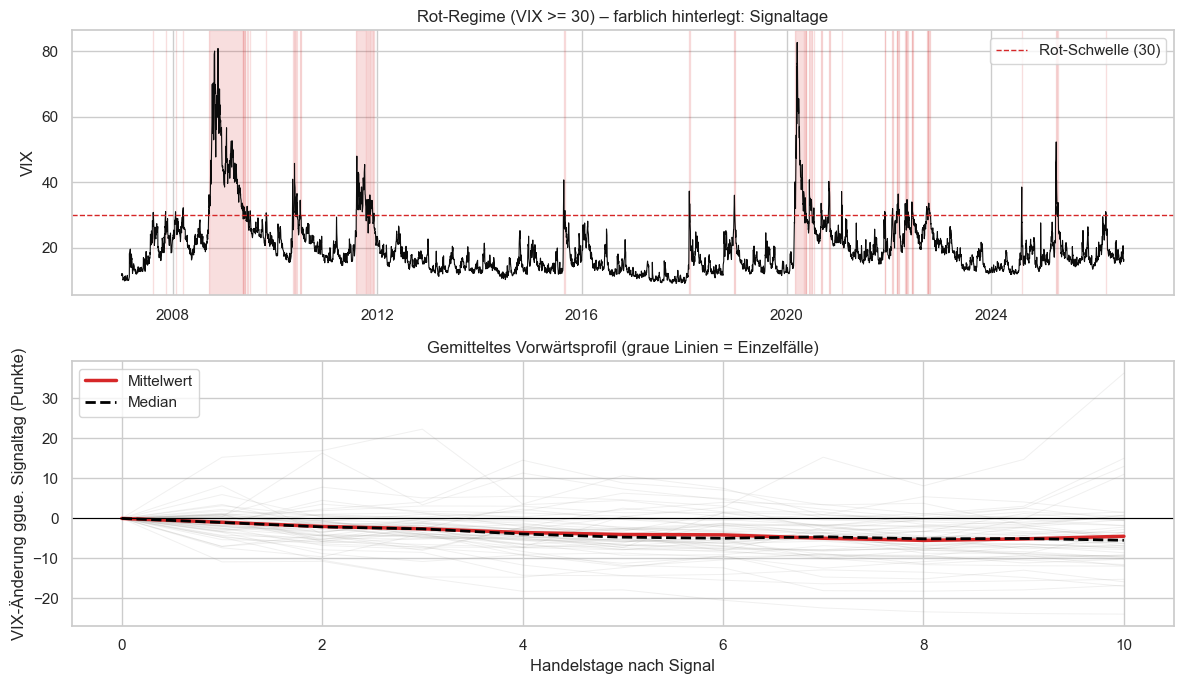

Anteil Handelstage mit Signal:             9.1%  (449 Tage)
Auswertbare Ereignisse (Vorwärtsprofil):   53
Trefferquote VIX > 30 in 10 Tagen:         79.2%  (Baseline: 15.2%)
Mittl. VIX-Änderung nach 5 / 10 Tagen:     -4.02 / -4.46 Punkte
Median max. VIX-Anstieg im 10-Tage-Fenster:  +0.45 Punkte


In [31]:
res_rot = vertiefte_einzelbetrachtung(
    "Rot-Regime", sig_rot, ereignis_maske=sig_rot_eintritt,
    titel="Rot-Regime (VIX >= 30)", farbe=COLOR_RED)


**Ergebnis:** Der VIX ist an 9,1 % der Tage im Rot-Bereich; ausgewertet werden
die 53 Eintrittsereignisse. Erwartungsgemäß ist die Trefferquote trivial hoch
(79,2 %), da der VIX beim Eintritt bereits nahe 30 liegt. Das Vorwärtsprofil
fällt danach im Mittel deutlich (−4,02 / −4,46), und ein großer weiterer
Anstieg ist selten (medianer max. Anstieg nur +0,45).

**Praxisrelevanz für das Ampelsystem:** Die Einzelbetrachtung untermauert den
Befund aus H5: Ein Rot-Eintritt ist meist ein kurzer Ausschlag mit
anschließender Beruhigung, kein Auftakt zu immer weiter steigender Panik. Das
stützt die Empfehlung, einen einzelnen Rot-Tag nicht zu überzeichnen und erst
bei mehrtägiger Persistenz zu eskalieren.

### 5.3 Konsolidierte Übersicht und Einordnung

Gegenüberstellung der vier Signale anhand der VIX-spezifischen Kennzahlen.


In [32]:
uebersicht = pd.DataFrame([res_3m, res_div, res_rot]).set_index("name")
uebersicht_anzeige = pd.DataFrame({
    "Anteil Tage": uebersicht["anteil_tage"].map(lambda x: f"{x:.1%}"),
    "Ereignisse": uebersicht["n_ereignisse"].astype(int),
    "Trefferquote (VIX>30/10T)": uebersicht["trefferquote"].map(lambda x: f"{x:.1%}"),
    "VIX-Änderung 5T": uebersicht["aenderung_5"].map(lambda x: f"{x:+.2f}"),
    "VIX-Änderung 10T": uebersicht["aenderung_10"].map(lambda x: f"{x:+.2f}"),
    "Median max. Anstieg 10T": uebersicht["median_max_anstieg"].map(lambda x: f"{x:+.2f}"),
})
uebersicht_anzeige.insert(0, "Baseline (VIX>30/10T)", f"{baseline_10:.1%}")
print(uebersicht_anzeige.to_string())


                    Baseline (VIX>30/10T) Anteil Tage  Ereignisse Trefferquote (VIX>30/10T) VIX-Änderung 5T VIX-Änderung 10T Median max. Anstieg 10T
name                                                                                                                                                
3-Monats-Hoch                       15.2%        3.1%         153                     41.8%           -2.47            -2.92                   +1.23
Divergenz (Block 6)                 15.2%        1.1%          56                     25.0%           +2.53            +2.45                   +4.09
Rot-Regime                          15.2%        9.1%          53                     79.2%           -4.02            -4.46                   +0.45


**Zusammenfassende Einordnung:** Die betrachteten Signale zerfallen klar in zwei
Charakteristiken. **Gleichlaufende/beruhigende Signale** treten auf bereits
erhoehtem VIX-Niveau auf und zeigen ein im Mittel *fallendes* Vorwaerts-Profil:
das 3-Monats-Hoch (−2,92 nach 10 Tagen) und der Rot-Eintritt (−4,46) – und, in
Abschnitt 4.7 gesondert gezeigt, auch die 3-Punkte-Umkehr (−2,48). Sie
beschreiben den *aktuellen* Zustand, sind aber keine Vorboten. Demgegenueber ist
die **Divergenz Block 6** das einzige Signal mit *steigendem* Vorwaerts-Profil
(+2,45) und dem groessten medianen Folge-Anstieg (+4,09) – und damit der einzige
echte **vorlaufende** Fruehindikator im Katalog.

Fuer das Ampelsystem folgt daraus eine klare Arbeitsteilung: Die Rot-Schwelle und
die begleitenden Signale beschreiben den aktuellen Zustand, waehrend Block 6 als
vorlaufendes Zusatz-Warnsignal dienen kann – im Rahmen seiner noch schmalen
Datenbasis (56 Faelle). Alle Kennzahlen sind explorativ und beschreiben
historische Durchschnitte, keine garantierten Prognosen.


## 6. Was-wäre-wenn-Analyse: Wirkung des VIX-gestützten Risikoausschlusses

Die bisherigen Abschnitte beschreiben den Marktzustand. Dieser Abschnitt nimmt
die Perspektive einer Anlegerin ein und beantwortet die Frage direkt: **Wie
hätte sich die Wertentwicklung des S&P 500 unterschieden, wenn man an den vom
VIX als riskant eingestuften Tagen nicht investiert gewesen wäre?** Dazu wird
die Wertentwicklung von **Buy & Hold** (durchgehend im S&P 500 investiert) einer
**Ausschluss-Strategie** gegenübergestellt, die an VIX-Risikotagen in Cash geht.

**Methodische Abgrenzung:** Das VIX-Signal ist am jeweiligen Handelsschluss
bekannt und wird um einen Tag verschoben angewendet (Entscheidung am
Vortagsschluss → die Strategie ist frei von Rückschaufehlern/Look-ahead-Bias).
An ausgeschlossenen Tagen beträgt die Tagesrendite 0 %. Vereinfachend werden
**Transaktionskosten und eine Verzinsung der Cash-Position nicht** berücksichtigt.
Die Ergebnisse zeigen daher das **theoretische Potenzial** einer VIX-gestützten
Risikosteuerung, nicht die realistisch erzielbare Rendite einer handelbaren Strategie.

**Wichtiger Vorbehalt zum VIX:** Hohe VIX-Werte markieren historisch nicht nur
Abschwünge, sondern fallen oft mit dem Tiefpunkt und der anschließenden,
besonders kräftigen Erholung zusammen. Ein Ausschluss von Hoch-VIX-Tagen
vermeidet daher zwar Verlusttage, kann aber auch starke Erholungstage verpassen –
dieser Zielkonflikt ist bei der Interpretation der Renditen zentral.


### 6.1 Backtest-Hilfsfunktionen

`was_waere_wenn` berechnet für eine gegebene Risikomaske die Wertentwicklung
beider Varianten sowie Gesamtrendite, annualisierte Rendite (CAGR) und den
historischen maximalen Drawdown.


In [33]:
def historischer_max_drawdown(werte):
    # Klassischer Peak-to-Trough-Drawdown einer kumulierten Wertreihe.
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_waere_wenn(risiko_maske, label):
    '''Simuliert eine Strategie, die an VIX-Risikotagen in Cash geht (Tagesrendite 0,
    ohne Cash-Verzinsung und Transaktionskosten) und sonst voll im S&P 500 investiert
    ist. Das VIX-Signal wird um einen Tag verschoben angewendet (Entscheidung am
    Vortagsschluss -> kein Look-ahead-Bias). Vergleich mit Buy & Hold.'''
    tagesrendite = df["sp500_close"].pct_change().fillna(0)
    risiko = risiko_maske.reindex(df.index).fillna(False).shift(1, fill_value=False)

    strategie_rendite = tagesrendite.where(~risiko, 0.0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity):
        gesamt = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamt, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "risikophase": label,
        "anteil_risikotage": risiko.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Backtest-Hilfsfunktionen definiert.")


Backtest-Hilfsfunktionen definiert.


### 6.2 VIX-Risikophasen-Definitionen

Aus den Erkenntnissen der Kapitel 4 und 5 werden fünf Risikophasen abgeleitet.
Für die ereignisbasierten Signale (3-Monats-Hoch, Divergenz Block 6) gilt das
Risiko am Signaltag und den darauf folgenden 9 Handelstagen (10-Tage-Fenster,
konsistent zur Turbulenz-Definition aus Abschnitt 4.6):

- **Rot (VIX ≥ 30)** – der Ausnahmezustand der Ampel.
- **Gelb+Rot (VIX ≥ 20)** – alle angespannten und schlimmeren Tage.
- **3-Monats-Hoch (+10 Tage)** – Frühwarnfenster nach einem neuen 3-Monats-Hoch (H6).
- **Divergenz Block 6 (+10 Tage)** – Fenster nach dem vorlaufenden Divergenzsignal (H9).
- **Kombiniert (Rot oder Block 6)** – Rot-Zustand ODER laufendes Block-6-Frühwarnfenster.


In [34]:
# Nachlauf-Fenster: Risiko gilt am Signaltag und den folgenden k-1 Handelstagen
def nachlauf(signal, k=10):
    maske = signal.reindex(df.index).fillna(False)
    return maske.rolling(k, min_periods=1).max().astype(bool)

# Signale konsistent zu Kapitel 4/5 rekonstruieren
_sig_3m_hoch = df["vix_close"] > df["vix_close"].shift(1).rolling(63).max()
_co_up = (df["sp500_return"] > 0.25) & (df["vix_change"] > 0)
_sig_divergenz = _co_up.rolling(20).mean() > 0.20

risiko_definitionen = {
    "Rot (VIX >= 30)":            df["vix_close"] >= 30,
    "Gelb+Rot (VIX >= 20)":       df["vix_close"] >= 20,
    "3-Monats-Hoch (+10 Tage)":   nachlauf(_sig_3m_hoch, 10),
    "Divergenz Block 6 (+10 Tage)": nachlauf(_sig_divergenz, 10),
}
risiko_definitionen["Kombiniert (Rot oder Block 6)"] = (
    (df["vix_close"] >= 30) | nachlauf(_sig_divergenz, 10)
)

print("VIX-Risikophasen (Anteil der Handelstage):")
for _name, _maske in risiko_definitionen.items():
    print(f"  {_name:32s}: {_maske.mean():.1%}")


VIX-Risikophasen (Anteil der Handelstage):
  Rot (VIX >= 30)                 : 9.1%
  Gelb+Rot (VIX >= 20)            : 35.9%
  3-Monats-Hoch (+10 Tage)        : 15.8%
  Divergenz Block 6 (+10 Tage)    : 2.5%
  Kombiniert (Rot oder Block 6)   : 11.4%


### 6.3 Konsolidierte Kennzahlenübersicht

Für alle fünf Risikophasen werden Gesamtrendite, CAGR und maximaler Drawdown
von Buy & Hold der jeweiligen Ausschluss-Strategie gegenübergestellt.


In [35]:
ergebnisse_www = [was_waere_wenn(maske, name) for name, maske in risiko_definitionen.items()]
tabelle_www = pd.DataFrame(ergebnisse_www).drop(columns=["equity_buy_hold", "equity_strategie"])

anzeige = pd.DataFrame({
    "Anteil Risikotage": tabelle_www["anteil_risikotage"].map(lambda x: f"{x:.1%}"),
    "Gesamtrend. B&H": tabelle_www["gesamtrendite_buy_hold"].map(lambda x: f"{x:.0%}"),
    "Gesamtrend. Strat.": tabelle_www["gesamtrendite_strategie"].map(lambda x: f"{x:.0%}"),
    "CAGR B&H": tabelle_www["cagr_buy_hold"].map(lambda x: f"{x:.1%}"),
    "CAGR Strat.": tabelle_www["cagr_strategie"].map(lambda x: f"{x:.1%}"),
    "Max DD B&H": tabelle_www["max_drawdown_buy_hold"].map(lambda x: f"{x:.1%}"),
    "Max DD Strat.": tabelle_www["max_drawdown_strategie"].map(lambda x: f"{x:.1%}"),
})
anzeige.index = tabelle_www["risikophase"]
print(anzeige.to_string())


                              Anteil Risikotage Gesamtrend. B&H Gesamtrend. Strat. CAGR B&H CAGR Strat. Max DD B&H Max DD Strat.
risikophase                                                                                                                     
Rot (VIX >= 30)                            9.1%            446%               250%     9.1%        6.6%     -56.8%        -36.8%
Gelb+Rot (VIX >= 20)                      35.9%            446%               112%     9.1%        3.9%     -56.8%        -20.1%
3-Monats-Hoch (+10 Tage)                  15.8%            446%               270%     9.1%        6.9%     -56.8%        -54.4%
Divergenz Block 6 (+10 Tage)               2.5%            446%               439%     9.1%        9.0%     -56.8%        -56.8%
Kombiniert (Rot oder Block 6)             11.4%            446%               253%     9.1%        6.7%     -56.8%        -36.8%


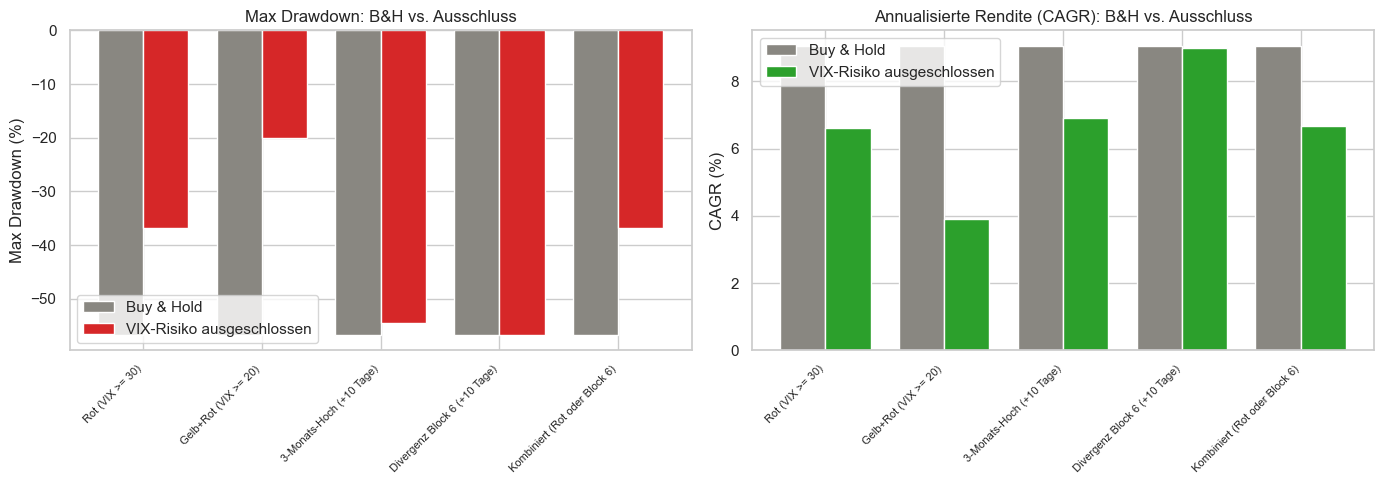

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(tabelle_www)); breite = 0.38
namen = tabelle_www["risikophase"]

ax1.bar(x - breite/2, tabelle_www["max_drawdown_buy_hold"]*100, breite, label="Buy & Hold", color=COLOR_MUTED)
ax1.bar(x + breite/2, tabelle_www["max_drawdown_strategie"]*100, breite, label="VIX-Risiko ausgeschlossen", color=COLOR_RED)
ax1.set_xticks(x); ax1.set_xticklabels(namen, rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Max Drawdown (%)"); ax1.set_title("Max Drawdown: B&H vs. Ausschluss"); ax1.legend()

ax2.bar(x - breite/2, tabelle_www["cagr_buy_hold"]*100, breite, label="Buy & Hold", color=COLOR_MUTED)
ax2.bar(x + breite/2, tabelle_www["cagr_strategie"]*100, breite, label="VIX-Risiko ausgeschlossen", color=COLOR_GREEN)
ax2.set_xticks(x); ax2.set_xticklabels(namen, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("CAGR (%)"); ax2.set_title("Annualisierte Rendite (CAGR): B&H vs. Ausschluss"); ax2.legend()

plt.tight_layout(); plt.show()


**Ergebnis:** Buy & Hold erzielt über den Zeitraum 446 % Gesamtrendite
(CAGR 9,1 %) bei einem maximalen Drawdown von −56,8 %. Über alle fünf
Risikophasen hinweg senkt der VIX-gestützte Ausschluss zwar den Drawdown,
**reduziert aber zugleich die Rendite** – anders als im SMA-Notebook, wo der
Ausschluss beide Kennzahlen verbesserte. Der Ausschluss der Rot-Tage (VIX ≥ 30,
9,1 % der Tage) drückt den Max Drawdown auf −36,8 %, kostet aber CAGR (6,6 %).
Am deutlichsten zeigt sich der Zielkonflikt bei Gelb+Rot (VIX ≥ 20): Der
Drawdown fällt stark auf −20,1 %, die CAGR jedoch auf 3,9 %. Die ereignis-
basierten Signale bewegen die Gesamtbilanz kaum – das 3-Monats-Hoch (+10 T)
senkt den Drawdown nur minimal (−54,4 %), und Block 6 (+10 T) betrifft mit
2,5 % der Tage zu wenige Tage, um die Equity-Kurve überhaupt spürbar zu
verändern (CAGR 9,0 %, Drawdown unverändert).

**Ursache:** Hohe VIX-Werte fallen historisch mit Markttiefpunkten und den
anschließenden, besonders kräftigen Erholungstagen zusammen. Wer an
Hoch-VIX-Tagen in Cash geht, vermeidet Verlusttage, verpasst aber auch die
stärksten Rebounds – der VIX wirkt daher als Risikoreduzierer, nicht als
Renditebringer (im Einklang mit H2, Abschnitt 4.2).


### 6.4 Vertiefte Einzelbetrachtung ausgewählter Risikophasen

Für drei repräsentative Fälle wird der zeitliche Verlauf dargestellt: oben der
S&P-500-Kurs mit rot hinterlegter Ausschlussphase, darunter die Wertentwicklung
von Buy & Hold gegenüber der Ausschluss-Strategie (logarithmische Skala,
Startwert = 1).


In [37]:
def plotte_was_waere_wenn(label, titel=None):
    ergebnis = was_waere_wenn(risiko_definitionen[label], label)
    risiko = risiko_definitionen[label].reindex(df.index).fillna(False).shift(1, fill_value=False)
    titel = titel or label

    fig, (ax_kurs, ax_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    ax_kurs.fill_between(df.index, 0, 1, where=risiko.values, color=COLOR_RED, alpha=0.15,
                         transform=ax_kurs.get_xaxis_transform())
    ax_kurs.plot(df.index, df["sp500_close"], color=COLOR_PRICE, linewidth=0.9)
    ax_kurs.set_ylabel("S&P 500 (Punkte)")
    ax_kurs.set_title(f"{titel} - rot hinterlegt: ausgeschlossene VIX-Risikophase")

    ax_equity.plot(df.index, ergebnis["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
    ax_equity.plot(df.index, ergebnis["equity_strategie"], color=COLOR_GREEN, label="VIX-Risiko ausgeschlossen")
    ax_equity.set_yscale("log")
    ax_equity.set_ylabel("Wertentwicklung (Start = 1, log.)")
    ax_equity.legend()

    fig.tight_layout(); plt.show()

    print(f"Anteil ausgeschlossener Handelstage: {ergebnis['anteil_risikotage']:.1%}")
    print(f"Gesamtrendite - B&H: {ergebnis['gesamtrendite_buy_hold']:.0%} | Strategie: {ergebnis['gesamtrendite_strategie']:.0%}")
    print(f"CAGR         - B&H: {ergebnis['cagr_buy_hold']:.1%} | Strategie: {ergebnis['cagr_strategie']:.1%}")
    print(f"Max Drawdown - B&H: {ergebnis['max_drawdown_buy_hold']:.1%} | Strategie: {ergebnis['max_drawdown_strategie']:.1%}")
    return ergebnis


#### Rot (VIX ≥ 30) ausgeschlossen


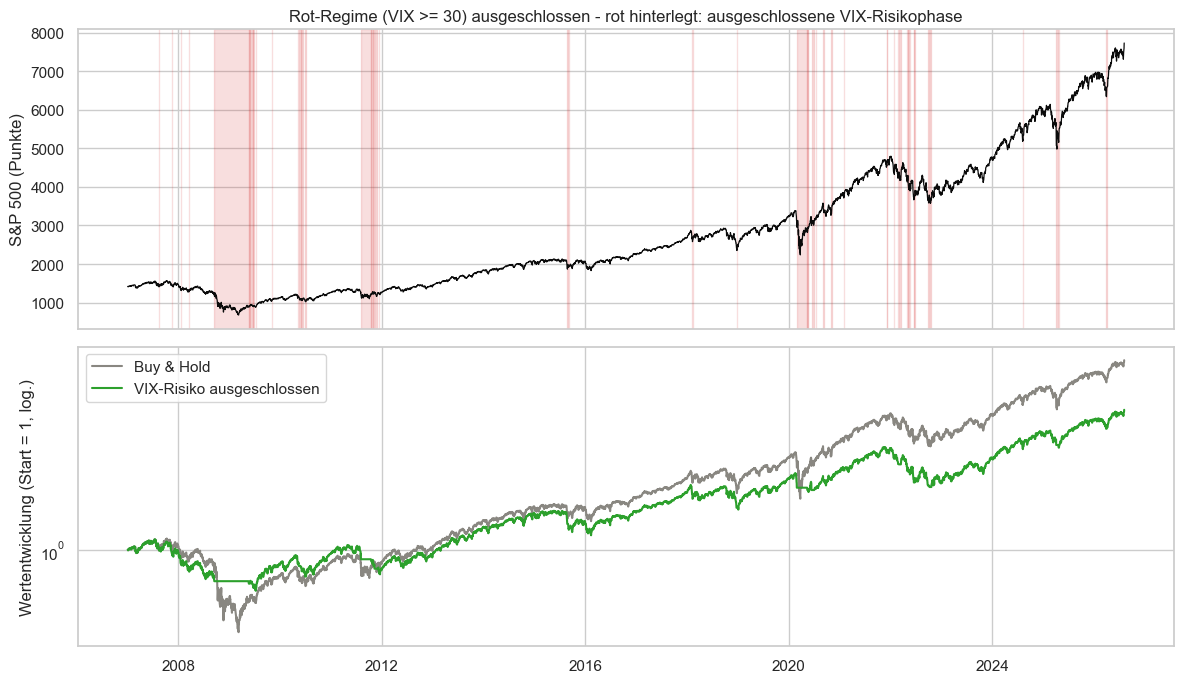

Anteil ausgeschlossener Handelstage: 9.1%
Gesamtrendite - B&H: 446% | Strategie: 250%
CAGR         - B&H: 9.1% | Strategie: 6.6%
Max Drawdown - B&H: -56.8% | Strategie: -36.8%


In [38]:
_ = plotte_was_waere_wenn("Rot (VIX >= 30)", "Rot-Regime (VIX >= 30) ausgeschlossen")


**Ergebnis:** Der Ausschluss der 9,1 % Rot-Tage senkt den Max Drawdown von
−56,8 % auf −36,8 % (−20 Prozentpunkte weniger Risiko), drückt aber die CAGR
von 9,1 % auf 6,6 %. Die Equity-Kurve zeigt das Muster deutlich: In den Crashs
2008 und 2020 bleibt die Strategie flach (kein Absturz), verpasst danach aber
die V-förmigen Erholungen und bleibt so dauerhaft unter Buy & Hold. Für ein
kapitalerhaltendes Ziel ein sinnvoller Trade-off, für Renditemaximierung nicht.


#### Gelb+Rot (VIX ≥ 20) ausgeschlossen


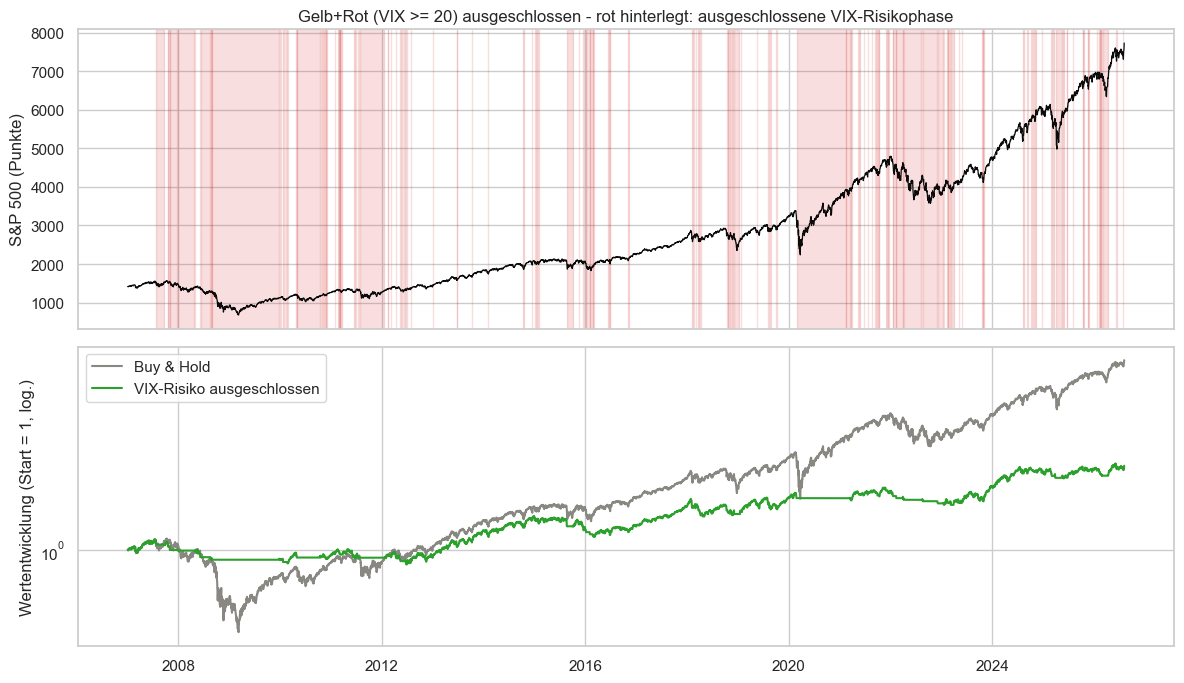

Anteil ausgeschlossener Handelstage: 35.9%
Gesamtrendite - B&H: 446% | Strategie: 112%
CAGR         - B&H: 9.1% | Strategie: 3.9%
Max Drawdown - B&H: -56.8% | Strategie: -20.1%


In [39]:
_ = plotte_was_waere_wenn("Gelb+Rot (VIX >= 20)", "Gelb+Rot (VIX >= 20) ausgeschlossen")


**Ergebnis:** Das aggressivste Filter (35,9 % der Tage in Cash) mehr als
halbiert den Max Drawdown auf −20,1 %, kostet aber massiv Rendite: Die CAGR
sinkt auf 3,9 % (Gesamtrendite 112 % statt 446 %). Wer stark schwankungsavers
ist, erhält ein deutlich ruhigeres Depot – der Renditeverzicht ist jedoch
erheblich und für die meisten Anlegerinnen zu hoch.


#### Kombinierte Regel (Rot oder Block 6) ausgeschlossen


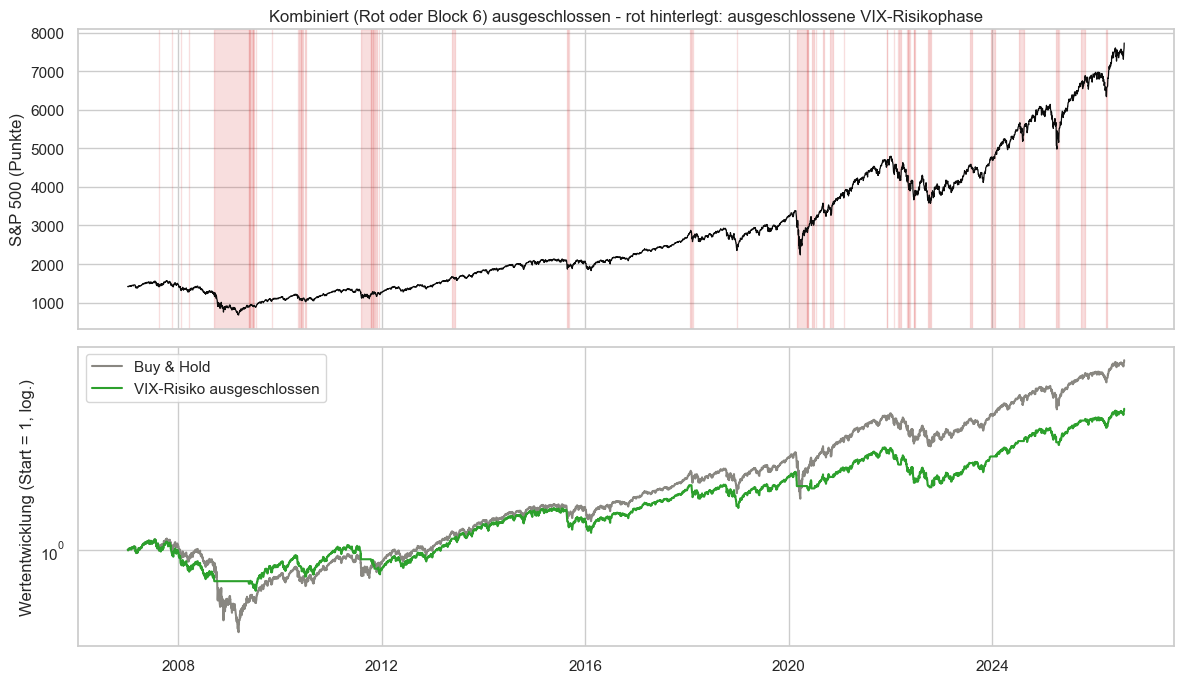

Anteil ausgeschlossener Handelstage: 11.4%
Gesamtrendite - B&H: 446% | Strategie: 253%
CAGR         - B&H: 9.1% | Strategie: 6.7%
Max Drawdown - B&H: -56.8% | Strategie: -36.8%


In [40]:
_ = plotte_was_waere_wenn("Kombiniert (Rot oder Block 6)", "Kombiniert (Rot oder Block 6) ausgeschlossen")


**Ergebnis:** Die Kombination ist praktisch identisch zum reinen Rot-Ausschluss
(Block 6 fügt nur ~2 Prozentpunkte zusätzliche Tage hinzu): Max Drawdown −36,8 %,
CAGR 6,7 %. Der vorlaufende Block-6-Filter verbessert das aggregierte
Portfolio-Ergebnis also nicht spürbar – sein Wert liegt in der frühen
Einzelwarnung (Kapitel 5), nicht in der Portfolio-Steuerung, da er zu wenige
Tage abdeckt.


### 6.5 Zusammenfassende Einordnung

Die Was-wäre-wenn-Analyse liefert den zentralen, ehrlichen Befund: Ein
VIX-gestützter Risikoausschluss **reduziert zuverlässig den maximalen Drawdown,
aber auf Kosten der Rendite** – im Gegensatz zum trendbasierten SMA-Ansatz, der
beide Ziele zugleich verbesserte. Der Grund liegt in der Natur des VIX: Er ist
ein zeitgleicher Stressindikator, dessen Spitzen mit Tiefpunkten und den
darauffolgenden Erholungen zusammenfallen; ein Ausschluss dieser Tage vermeidet
Verluste und Gewinne gleichermaßen.

**Für das Ampelsystem** heißt das: Der Nutzen liegt in der Kapitalerhaltung bzw.
Drawdown-Begrenzung, nicht in der Renditesteigerung. Je nach Risikoneigung bietet
die Rot-Schwelle (VIX ≥ 30) einen moderaten Trade-off (Drawdown −20 Prozentpunkte
bei −2,5 Prozentpunkten CAGR), während Gelb+Rot (VIX ≥ 20) für sehr
sicherheitsorientierte Anlegerinnen den Drawdown mehr als halbiert, aber viel
Rendite kostet. Diese Erkenntnis deckt sich mit H2: Die Ampel sollte als
**Risiko-, nicht als Renditesignal** kommuniziert werden. Sämtliche Werte beruhen
auf einer vereinfachten Simulation ohne Transaktionskosten und Cash-Verzinsung
und markieren ein oberes Potenzial, keine handelbare Rendite.


## 7. Fazit und Handlungsempfehlungen

Die explorative Analyse bestätigt, dass ein VIX-basiertes Ampelsystem auf einer
soliden empirischen Grundlage steht. Zusammenfassung der Befunde je Hypothese:

**Basis-Exploration (H1–H5):**

- **H1 (Ruhiges Fahrwasser vs. Stressphasen):** Bestätigt. VIX-Anteile Grün
  64,1 % / Gelb 26,8 % / Rot 9,1 %; deutliche Ausschläge nur in realen Krisen.
- **H2 (VIX vs. S&P-500-Renditen):** Bestätigt für die Tagesänderung (r = −0,815),
  nicht für das Niveau (r = −0,143) – Zustands-, kein Richtungsindikator.
- **H3 (Volatility Clustering):** Bestätigt. Autokorrelation 0,974 (Lag 1) /
  0,909 (Lag 5) – stabiles, nicht flackerndes Signal.
- **H4 (Verteilung & Schwellenwerte):** Bestätigt. Perzentile
  17,5 / 22,7 / 29,1 / 35,3 stützen die Faustregeln 20/30.
- **H5 (Dauer der Ampelphasen):** Rot meist kurz (Median 2 Tage), in Krisen aber
  bis 170 Tage – Eskalationsregel bei mehrtägigem Rot sinnvoll.

**Vertiefende Hypothesen (H6–H9):**

- **H6 (Neues 3-Monats-Hoch):** Frühwarnsignal, Trefferquote ~Faktor 3
  (39,2 % / 41,8 % vs. 12,3 % / 15,2 %).
- **H7 (3-Punkte-Umkehr):** Beruhigungssignal, 67,3 % der Fälle mit fallendem VIX.
- **H8 (VIX-Schwellenwerte):** Krisen-Median 31,77 stützt die Rot-Schwelle 30.
- **H9 (Divergenz):** Original nicht belastbar (5 Signale); nur Variante Block 6
  (20 T / 20 % / ≥ 0,25 %) schlägt die Baseline klar (25,0 % vs. 15,2 %).

Die **Vertiefte Einzelbetrachtung** (Abschnitt 5) bestätigt diese Befunde aus
der Einzelfall-Perspektive und macht die typische Vorlauf-/Nachlaufdynamik der
vier Ampel-relevanten Signale sichtbar.

Die **Was-wäre-wenn-Analyse** (Abschnitt 6) zeigt schließlich, dass ein
VIX-gestützter Ausschluss von Risikophasen den maximalen Drawdown des S&P 500
deutlich senkt (Rot-Ausschluss: −56,8 % → −36,8 %), dabei aber auch Rendite
kostet (CAGR 9,1 % → 6,6 %) – der VIX wirkt als Risiko-, nicht als Renditesignal.

**Abgeleitete Ampel-Logik (erster Entwurf):**

| Ampelfarbe | Basis-Kriterium | Optionaler Zusatzhinweis |
|---|---|---|
| Grün | VIX < 20 | „Vorsicht“-Flag bei aktivem 3-Monats-Hoch-Signal (H6) |
| Gelb | 20 ≤ VIX < 30 | – |
| Rot | VIX ≥ 30 | Hinweis „mögliche baldige Beruhigung“ bei 3-Punkte-Umkehr (H7) |

**Nächste Schritte:** Ampel-Logik inkl. Zusatzsignale als wiederverwendbare
Funktion(en) in `src/` implementieren, einen historischen Backtest der
kombinierten Regel durchführen, Unit-Tests mit den hier dokumentierten
Kennzahlen als Referenzwerten schreiben und die Divergenz-Variante Block 6 (H9)
mit wachsender Datenbasis regelmäßig nachprüfen.
